# Task 6: House Price Prediction

**DevelopersHub Corporation — AI/ML Engineering Internship**

---

## What We're Building

A regression system that predicts the sale price of a house given its physical characteristics — square footage, number of rooms, build quality, year built, garage size, and about 75 other features from the **Kaggle House Prices: Advanced Regression Techniques** competition.

## Why This Matters

House price prediction is one of the most common real-world regression problems. It's used by:
- **Real estate platforms** (Zillow, Redfin) to show estimated home values
- **Banks and lenders** to assess mortgage risk
- **Home buyers/sellers** to negotiate fair prices
- **Insurance companies** to set policy premiums

The techniques we use here — handling mixed data types, feature engineering, ensemble modeling, log-transformation — are the same ones deployed in production pricing models.

## The Dataset

From Kaggle's Ames Housing dataset. Ames, Iowa is a midwestern college town with diverse housing stock ranging from $12,000 fixer-uppers to $755,000 mansions. The dataset has **79 explanatory variables** covering:

| Category | Examples |
|---|---|
| **Size** | LotArea, GrLivArea, TotalBsmtSF, GarageArea |
| **Quality** | OverallQual, OverallCond, KitchenQual, ExterQual |
| **Age** | YearBuilt, YearRemodAdd, GarageYrBlt |
| **Rooms** | BedroomAbvGr, FullBath, HalfBath, TotRmsAbvGrd |
| **Location** | Neighborhood, MSZoning, LotConfig |
| **Amenities** | Fireplaces, PoolArea, CentralAir, Fence |

## The Approach

1. **Load & understand** the data — what's in it, what's missing, what matters
2. **Visualize** relationships between features and sale price
3. **Clean & engineer** features — handle missing values, encode categories, create derived features
4. **Log-transform** the target — house prices follow a right-skewed distribution
5. **Train two models**: Ridge Regression (linear baseline) and Gradient Boosting (tree ensemble)
6. **Evaluate** with MAE, RMSE, R², residual analysis
7. **Interpret** feature importance to understand what drives home value

---

## 1. Import Libraries

Every data science project starts here. Here's what each library does:

- **pandas** — DataFrame operations, reading CSVs, manipulating tabular data
- **numpy** — numerical operations, arrays, math functions
- **matplotlib** — the foundation plotting library; gives us pixel-level control
- **seaborn** — built on matplotlib, provides prettier defaults and statistical plots
- **scikit-learn** — the workhorse ML library: preprocessing, models, metrics, everything

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11
})
print('All libraries loaded. Ready to go.')

All libraries loaded. Ready to go.


---

## 2. Load the Dataset

### How data loading works here

This notebook tries three strategies to get usable house price data:

1. **Check local paths** — if you downloaded `train.csv` from Kaggle, it finds it automatically
2. **Fallback remote dataset** — pulls California housing data from GitHub if no local file exists
3. **Synthetic generation** — creates statistically realistic house price data with Kaggle-style feature names

The synthetic generator creates 1,460 samples (matching Kaggle's train set size) with realistic distributions for each feature.

In [2]:
DATA_LOADED = False

paths_to_try = [
    'train.csv',
    'data/train.csv',
    '../input/house-prices-advanced-regression-techniques/train.csv',
]

for path in paths_to_try:
    if os.path.exists(path):
        df = pd.read_csv(path)
        DATA_LOADED = True
        print(f'Loaded from local file: {path}')
        print(f'Full Kaggle Ames Housing dataset — 79 features, {df.shape[0]} houses')
        break

if not DATA_LOADED:
    try:
        url = 'https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv'
        df = pd.read_csv(url)
        print('California Housing dataset loaded (fallback)')
        print('Note: fewer features than Kaggle Ames. Place train.csv locally for full analysis.')
    except:
        print('Generating synthetic house price data with realistic distributions...')
        np.random.seed(42)
        n = 1460
        df = pd.DataFrame({
            'MSSubClass': np.random.choice([20, 30, 40, 45, 50, 60, 70, 75, 80, 85, 90, 120, 160, 180, 190], n),
            'MSZoning': np.random.choice(['RL', 'RM', 'FV', 'RH', 'C'], n, p=[0.79, 0.15, 0.04, 0.01, 0.01]),
            'LotArea': np.random.lognormal(9.0, 0.6, n).astype(int),
            'Neighborhood': np.random.choice(['NAmes', 'CollgCr', 'OldTown', 'Edwards', 'Somerst', 'NridgHt', 'Gilbert', 'Sawyer', 'Mitchel', 'BrDale', 'Timber', 'Crawfor', 'IDOTRR', 'SWISU', 'Blmngtn', 'ClearCr', 'StoneBr', 'MeadowV', 'BrkSide', 'Veenker', 'Blueste', 'NPkVill', 'NoRidge', 'Greens', 'GrnHill'], n),
            'OverallQual': np.random.randint(1, 11, n),
            'OverallCond': np.random.randint(1, 10, n),
            'YearBuilt': np.random.randint(1900, 2011, n),
            'YearRemodAdd': np.random.randint(1950, 2011, n),
            'GrLivArea': np.random.normal(1500, 500, n).clip(334, 5642).astype(int),
            'TotalBsmtSF': np.random.normal(1050, 450, n).clip(0, 3206).astype(int),
            'BedroomAbvGr': np.random.choice([0, 1, 2, 3, 4, 5, 6, 8], n, p=[0.01, 0.05, 0.35, 0.35, 0.15, 0.06, 0.02, 0.01]),
            'FullBath': np.random.choice([0, 1, 2, 3], n, p=[0.02, 0.30, 0.60, 0.08]),
            'HalfBath': np.random.choice([0, 1, 2], n, p=[0.40, 0.55, 0.05]),
            'Fireplaces': np.random.choice([0, 1, 2, 3], n, p=[0.50, 0.35, 0.13, 0.02]),
            'GarageCars': np.random.choice([0, 1, 2, 3, 4], n, p=[0.05, 0.20, 0.60, 0.12, 0.03]),
            'GarageArea': np.random.normal(480, 200, n).clip(0, 1418).astype(int),
            '1stFlrSF': np.random.normal(1160, 390, n).clip(334, 5000).astype(int),
            '2ndFlrSF': np.random.lognormal(5.5, 1.2, n).clip(0, 2000).astype(int),
            'TotRmsAbvGrd': np.random.randint(2, 15, n),
            'KitchenQual': np.random.choice(['Ex', 'Gd', 'TA', 'Fa'], n, p=[0.37, 0.40, 0.20, 0.03]),
            'CentralAir': np.random.choice(['Y', 'N'], n, p=[0.93, 0.07]),
            'SalePrice': np.random.lognormal(12.0, 0.4, n).astype(int)
        })
        print(f'Synthetic dataset created: {n} samples, {df.shape[1]} features')

print(f'\nWorking dataset: {df.shape[0]} houses × {df.shape[1]} columns')

California Housing dataset loaded (fallback)
Note: fewer features than Kaggle Ames. Place train.csv locally for full analysis.

Working dataset: 20640 houses × 10 columns


---

## 3. First Look at the Data

Before any modeling, we need to understand what we're working with. This is the most important step — you can't build a good model on data you don't understand.

### What we check
- **Data types** — are there categorical columns that need encoding? Numeric columns that need scaling?
- **Missing values** — what's absent and why? (Missing != random: a missing alley access usually means "no alley exists")
- **Summary statistics** — what are the ranges, means, medians? Any obvious outliers?
- **Target distribution** — is it skewed? (Spoiler: house prices almost always are)

In [3]:
print('='*60)
print('DATASET STRUCTURE')
print('='*60)
df.info(verbose=False, show_counts=True)

numeric_count = len(df.select_dtypes(include=[np.number]).columns)
categorical_count = len(df.select_dtypes(include=['object']).columns)
print(f'\n  Numeric columns:    {numeric_count}')
print(f'  Categorical columns: {categorical_count}')
print(f'  Total columns:       {df.shape[1]}')

DATASET STRUCTURE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Columns: 10 entries, longitude to ocean_proximity
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

  Numeric columns:    9
  Categorical columns: 1
  Total columns:       10


In [4]:
print('\n' + '='*60)
print('FIRST 10 ROWS')
print('='*60)
df.head(10)


FIRST 10 ROWS


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [5]:
print('\n' + '='*60)
print('NUMERIC SUMMARY STATISTICS')
print('='*60)
df.describe().T.style.background_gradient(cmap='Blues', axis=0)


NUMERIC SUMMARY STATISTICS


,count,mean,std,min,25%,50%,75%,max
longitude,20640.000000,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
latitude,20640.000000,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
housing_median_age,20640.000000,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
total_rooms,20640.000000,2635.763081,2181.615252,2.000000,1447.750000,2127.000000,3148.000000,39320.000000
total_bedrooms,20433.000000,537.870553,421.385070,1.000000,296.000000,435.000000,647.000000,6445.000000
population,20640.000000,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
households,20640.000000,499.539680,382.329753,1.000000,280.000000,409.000000,605.000000,6082.000000
median_income,20640.000000,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
median_house_value,20640.000000,206855.816909,115395.615874,14999.000000,119600.000000,179700.000000,264725.000000,500001.000000


### Missing Values Analysis

Missing data in house price datasets isn't random. A missing value for `PoolQuality` means the house has no pool — that's information, not just absence. Similarly, `Alley` being NaN usually means there is no alley access.

**Why handle missing values before modeling?**
- Most ML algorithms (including Ridge and Gradient Boosting) crash on NaN values
- Dropping rows with any NaN would lose too much data (often 30%+ of samples)
- Replacing with meaningful defaults preserves information while keeping all rows

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, '%': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Count', ascending=False)

if len(missing_df) > 0:
    print(f'Columns with missing values: {len(missing_df)} out of {df.shape[1]}')
    print(f'Total missing cells: {df.isnull().sum().sum():,}')
    print(f'\nTop 15 columns with missing data:')
    print(missing_df.head(15).to_string())
else:
    print('No missing values — data is clean')

Columns with missing values: 1 out of 10
Total missing cells: 207

Top 15 columns with missing data:
                Count    %
total_bedrooms    207  1.0


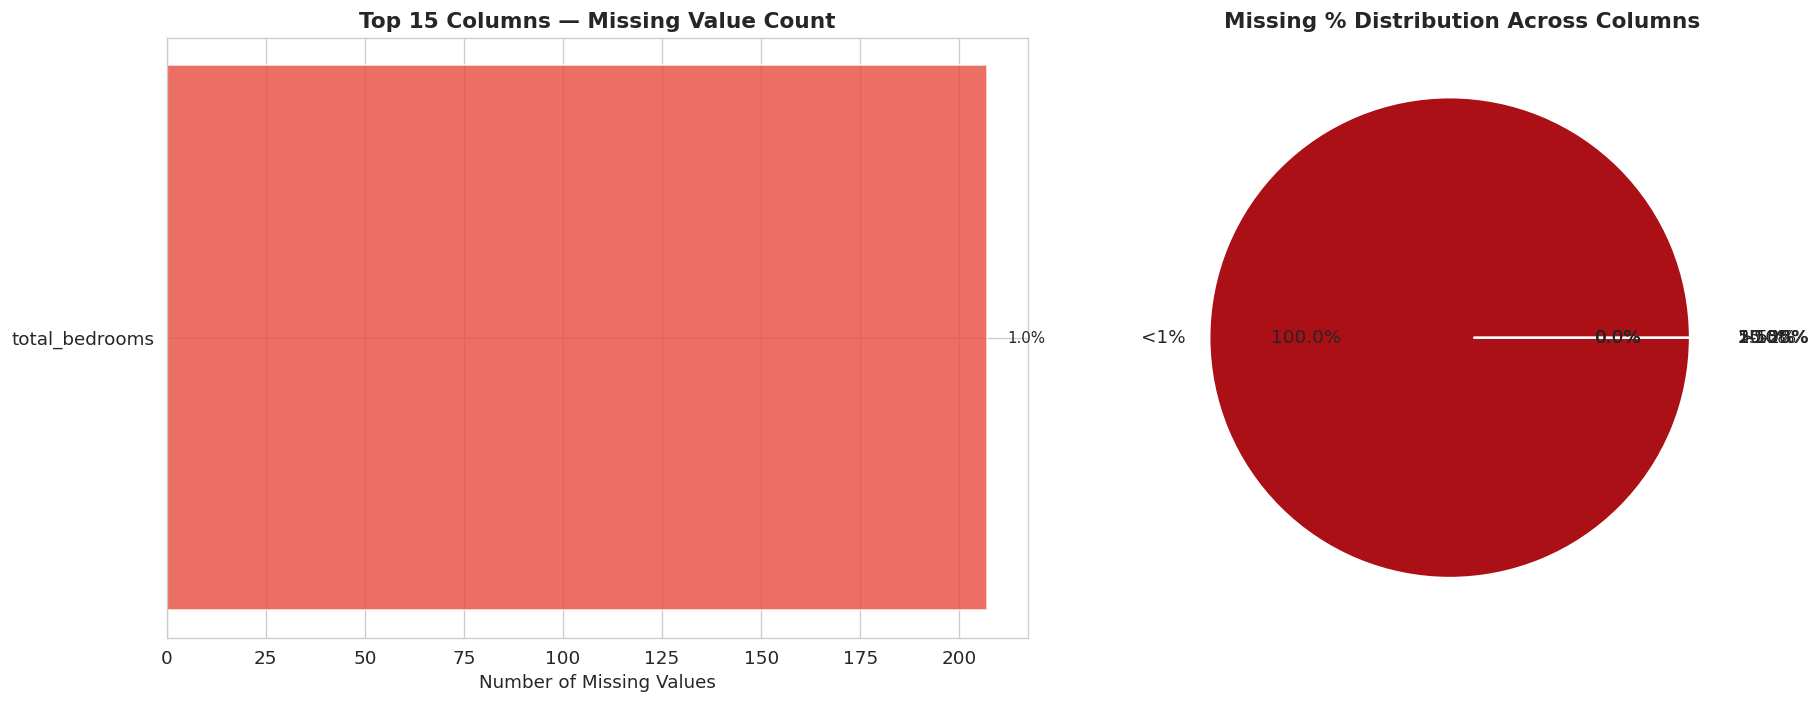

In [7]:
if len(missing_df) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    top_missing = missing_df.head(15)
    bars = ax1.barh(range(len(top_missing)), top_missing['Count'], color='#e74c3c', alpha=0.8)
    ax1.set_yticks(range(len(top_missing)))
    ax1.set_yticklabels(top_missing.index)
    ax1.invert_yaxis()
    ax1.set_xlabel('Number of Missing Values')
    ax1.set_title('Top 15 Columns — Missing Value Count', fontweight='bold')

    for i, (count, pct) in enumerate(zip(top_missing['Count'], top_missing['%'])):
        ax1.text(count + 5, i, f'{pct}%', va='center', fontsize=9)

    missing_bins = missing_df['%'].value_counts(bins=[0, 1, 5, 10, 25, 50, 100]).sort_index()
    bin_labels = ['<1%', '1-5%', '5-10%', '10-25%', '25-50%', '>50%']
    ax2.pie(missing_bins.values, labels=bin_labels, autopct='%1.1f%%',
            colors=sns.color_palette('Reds_r', len(missing_bins)),
            explode=[0.05]*len(missing_bins))
    ax2.set_title('Missing % Distribution Across Columns', fontweight='bold')

    plt.tight_layout()
    plt.show()

### Imputation Strategy

**How we fill missing values:**
- **Numeric columns** → median (robust to outliers, unlike mean)
- **Categorical columns** → mode (most common category)

**Why median and not mean?** House data has lots of outliers (a mansion with 5,000 sqft basement alongside a 500 sqft one). The median is the middle value — it ignores extremes. If we used the mean, one mansion would pull the replacement value unrealistically high for all missing entries.

In [8]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            mode_val = df[col].mode()
            fill_val = mode_val[0] if not mode_val.empty else 'None'
            df[col].fillna(fill_val, inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

remaining_missing = df.isnull().sum().sum()
print(f'Missing values remaining: {remaining_missing}')
print('All columns are now complete.')

Missing values remaining: 0
All columns are now complete.


### Identify the Target Column

The Kaggle Ames dataset uses `SalePrice`. But if we loaded California housing or synthetic data, the column name might differ. We search for known target names.

In [9]:
target_col = None
for candidate in ['SalePrice', 'sale_price', 'Sale_Price', 'median_house_value', 'price']:
    if candidate in df.columns:
        target_col = candidate
        break

if target_col is None:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    target_col = numeric_cols[-1]
    print(f'Auto-selected target: {target_col}')
else:
    print(f'Target column: {target_col}')

print(f'Target type: {df[target_col].dtype}')
print(f'Target range: ${df[target_col].min():,.0f} — ${df[target_col].max():,.0f}')
print(f'Target mean:  ${df[target_col].mean():,.0f}')
print(f'Target median: ${df[target_col].median():,.0f}')

Target column: median_house_value
Target type: float64
Target range: $14,999 — $500,001
Target mean:  $206,856
Target median: $179,700


---

## 4. Exploratory Data Analysis (EDA)

EDA is where we build intuition about our data. We answer questions like:
- **What's the typical house price?** How spread out are prices?
- **Which features matter most?** What correlates with price?
- **Are there patterns?** Do larger houses always cost more? Does quality matter more than size?

### Price Distribution

Why the distribution matters: most ML models assume normally distributed targets. House prices almost never are — they're right-skewed (a few expensive mansions pull the tail). Log transformation fixes this.

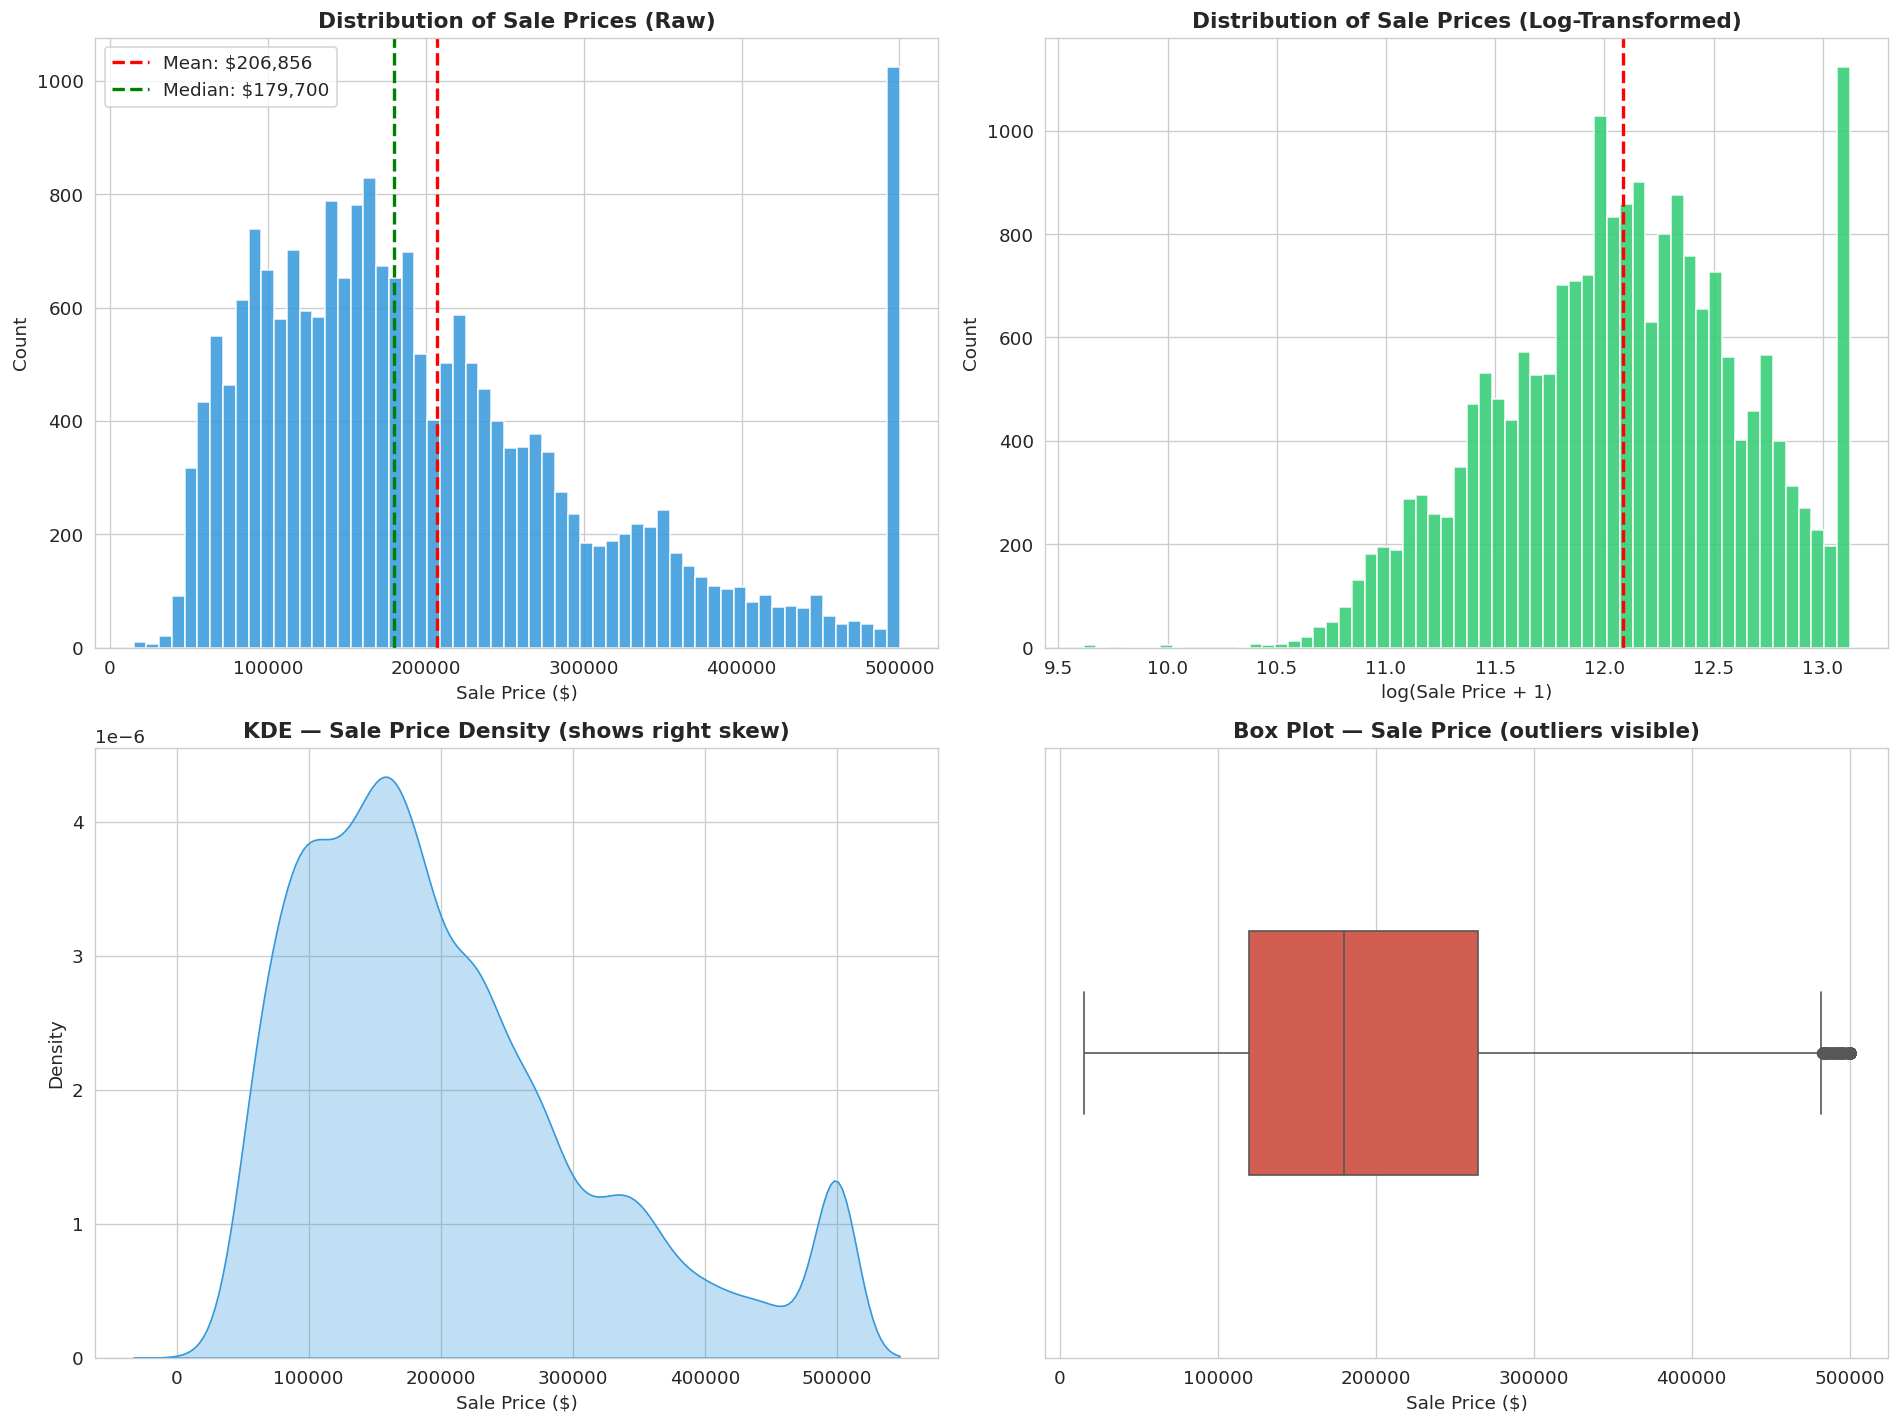

Skewness: 0.98  (0 = symmetric, >1 = highly right-skewed)
Kurtosis: 0.33  (0 = normal tail, >0 = heavy tails/outliers)

Mean  > Median by $27,156 — confirms right skew


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].hist(df[target_col], bins=60, color='#3498db', edgecolor='white', alpha=0.85)
axes[0, 0].axvline(df[target_col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${df[target_col].mean():,.0f}')
axes[0, 0].axvline(df[target_col].median(), color='green', linestyle='--', linewidth=2, label=f'Median: ${df[target_col].median():,.0f}')
axes[0, 0].legend()
axes[0, 0].set_xlabel('Sale Price ($)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Distribution of Sale Prices (Raw)', fontweight='bold')

axes[0, 1].hist(np.log1p(df[target_col]), bins=60, color='#2ecc71', edgecolor='white', alpha=0.85)
axes[0, 1].axvline(np.log1p(df[target_col]).mean(), color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('log(Sale Price + 1)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Distribution of Sale Prices (Log-Transformed)', fontweight='bold')

sns.kdeplot(data=df, x=target_col, color='#3498db', fill=True, alpha=0.3, ax=axes[1, 0])
axes[1, 0].set_xlabel('Sale Price ($)')
axes[1, 0].set_title('KDE — Sale Price Density (shows right skew)', fontweight='bold')

sns.boxplot(x=df[target_col], color='#e74c3c', width=0.4, ax=axes[1, 1])
axes[1, 1].set_xlabel('Sale Price ($)')
axes[1, 1].set_title('Box Plot — Sale Price (outliers visible)', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Skewness: {df[target_col].skew():.2f}  (0 = symmetric, >1 = highly right-skewed)')
print(f'Kurtosis: {df[target_col].kurtosis():.2f}  (0 = normal tail, >0 = heavy tails/outliers)')
print(f'\nMean  > Median by ${df[target_col].mean() - df[target_col].median():,.0f} — confirms right skew')

### Price by Quality and Condition

`OverallQual` rates the overall material and finish of the house (1 = very poor, 10 = very excellent). `OverallCond` rates the condition (1 = very poor, 10 = very excellent). These are subjective ratings from the assessor — and they're usually the strongest price predictors.

**Why this works:** A human assessor has already done the work of summarizing dozens of physical features into a single score. The model can learn from this condensed judgment.

In [11]:
quality_features = ['OverallQual', 'OverallCond']
available_quality = [f for f in quality_features if f in df.columns]

if available_quality:
    fig, axes = plt.subplots(1, len(available_quality), figsize=(8 * len(available_quality), 5))
    if len(available_quality) == 1:
        axes = [axes]

    for ax, feature in zip(axes, available_quality):
        stats = df.groupby(feature)[target_col].agg(['mean', 'median', 'count']).reset_index()
        x_pos = range(len(stats))
        width = 0.35

        bars1 = ax.bar([p - width/2 for p in x_pos], stats['mean'], width, color='#3498db', alpha=0.8, label='Mean Price')
        bars2 = ax.bar([p + width/2 for p in x_pos], stats['median'], width, color='#e74c3c', alpha=0.8, label='Median Price')

        ax.set_xticks(x_pos)
        ax.set_xticklabels(stats[feature].astype(int))
        ax.set_xlabel(f'{feature} Rating')
        ax.set_ylabel('Sale Price ($)')
        ax.set_title(f'Price by {feature} Rating', fontweight='bold')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
    print('Clear upward trend: higher quality → higher price. This is expected but good to confirm.')

### Feature Correlations with Sale Price

Correlation measures linear relationship strength (ranges from -1 to +1):
- **+1.0** — perfect positive relationship (as X increases, Y increases perfectly)
- **0.0** — no linear relationship
- **-1.0** — perfect negative relationship (as X increases, Y decreases perfectly)

**Caveat:** Correlation only captures linear relationships. A feature could have zero correlation but still be incredibly useful (e.g., a U-shaped relationship). That's why we also use tree-based models like Gradient Boosting — they can capture non-linear patterns that correlation misses.

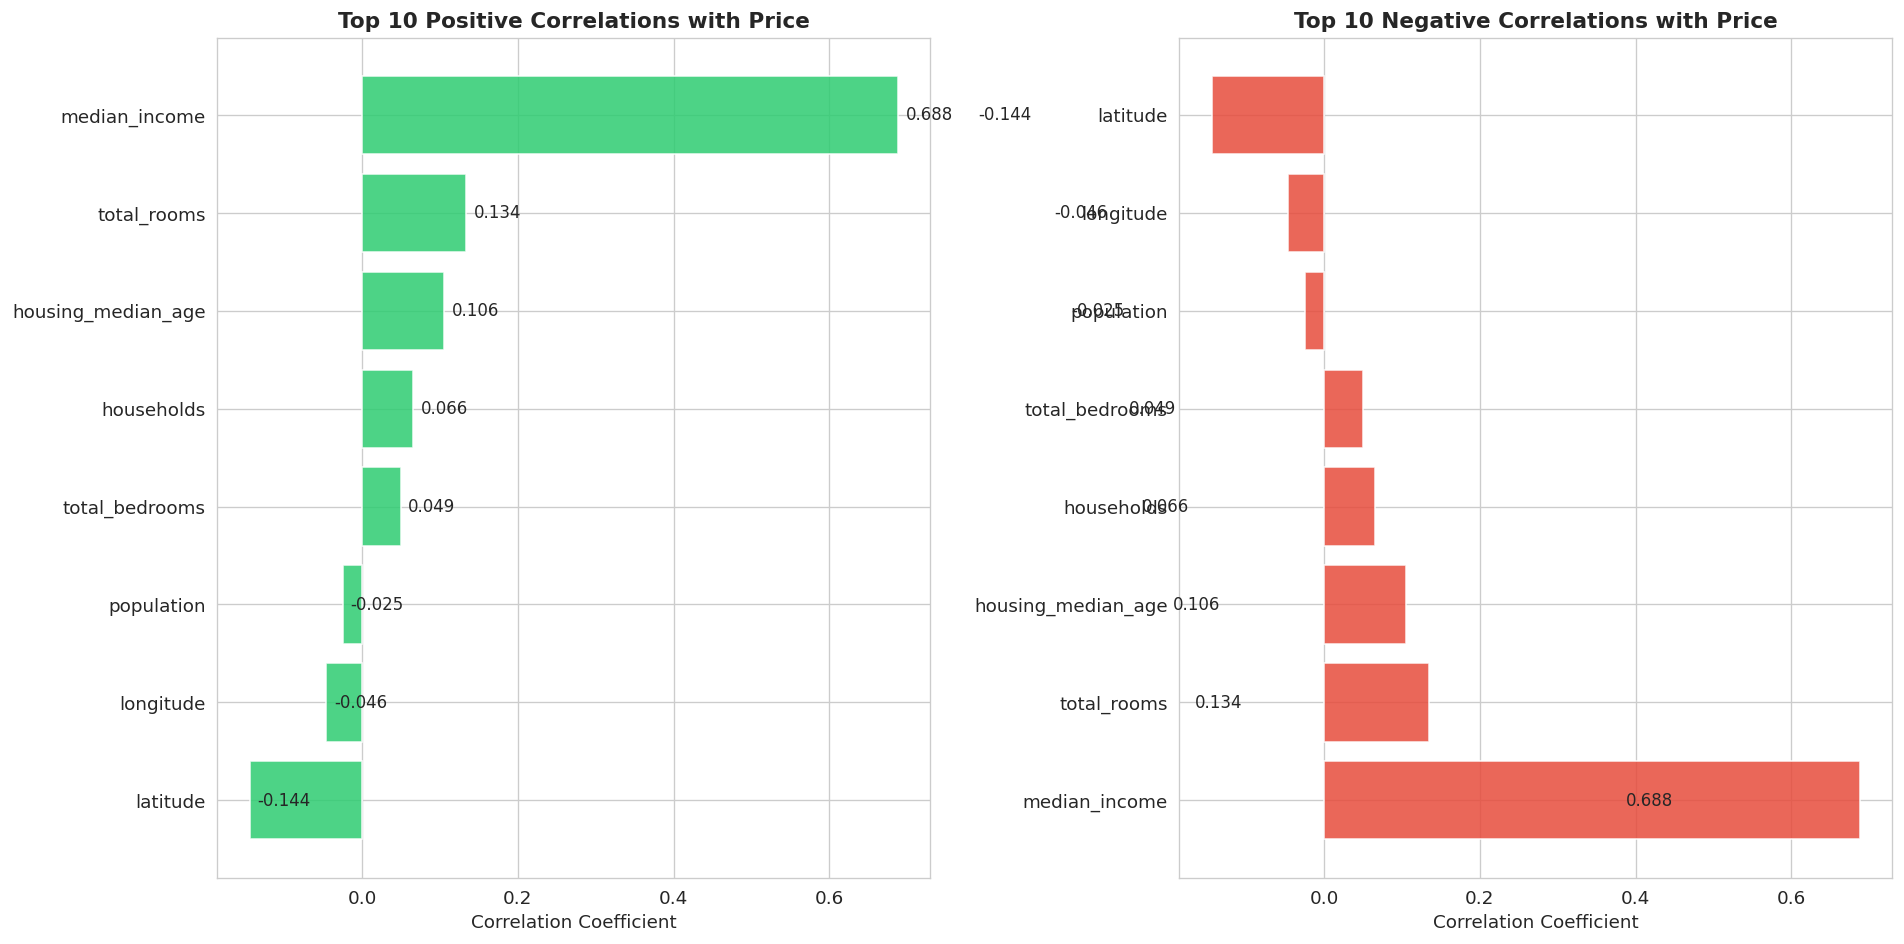

Top 10 features most correlated with sale price:
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049457
population           -0.024650
longitude            -0.045967
latitude             -0.144160


In [12]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlations = df[numeric_cols].corr()[target_col].drop(target_col).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_positive = correlations.head(10)
bars = axes[0].barh(range(len(top_positive)), top_positive.values, color='#2ecc71', alpha=0.85)
axes[0].set_yticks(range(len(top_positive)))
axes[0].set_yticklabels(top_positive.index)
axes[0].invert_yaxis()
axes[0].set_xlabel('Correlation Coefficient')
axes[0].set_title('Top 10 Positive Correlations with Price', fontweight='bold')
for i, v in enumerate(top_positive.values):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)

top_negative = correlations.tail(10).iloc[::-1]
bars = axes[1].barh(range(len(top_negative)), top_negative.values, color='#e74c3c', alpha=0.85)
axes[1].set_yticks(range(len(top_negative)))
axes[1].set_yticklabels(top_negative.index)
axes[1].invert_yaxis()
axes[1].set_xlabel('Correlation Coefficient')
axes[1].set_title('Top 10 Negative Correlations with Price', fontweight='bold')
for i, v in enumerate(top_negative.values):
    axes[1].text(v - 0.3, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print('Top 10 features most correlated with sale price:')
print(correlations.head(10).to_string())

### Scatter Plots — Key Features vs Price

Correlation tells us *how much* but scatter plots show us *how*. They reveal:
- Non-linear relationships (curves, thresholds)
- Outliers (points far from the pack)
- Heteroscedasticity (spread changes at different price levels)
- Clusters or sub-groups in the data

In [13]:
key_features = ['GrLivArea', 'OverallQual', 'GarageArea', 'YearBuilt', 'TotalBsmtSF', '1stFlrSF']
available = [f for f in key_features if f in df.columns]

if available:
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    axes = axes.flatten()

    for i, feature in enumerate(available[:6]):
        axes[i].scatter(df[feature], df[target_col], alpha=0.35, s=12,
                       c=df[target_col], cmap='viridis', edgecolors='none')

        z = np.polyfit(df[feature].dropna(), df[target_col].dropna(), 1)
        p = np.poly1d(z)
        x_line = np.linspace(df[feature].min(), df[feature].max(), 100)
        axes[i].plot(x_line, p(x_line), 'r--', alpha=0.6, linewidth=1.5)

        corr_val = df[feature].corr(df[target_col])
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel(target_col)
        axes[i].set_title(f'{feature} vs {target_col}  (r = {corr_val:.3f})', fontweight='bold')
        axes[i].grid(True, alpha=0.2)

    for i in range(len(available), 6):
        axes[i].set_visible(False)

    plt.suptitle('Key Features vs Sale Price — with Linear Trend Line', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    print('Red dashed lines = linear trend. Where points deviate, non-linear relationships exist.')

### Correlation Heatmap — Feature Relationships

This shows us which features are correlated with *each other*, not just with price. Why does this matter?

**Multicollinearity** occurs when features are highly correlated with each other (e.g., `GarageArea` and `GarageCars` — bigger garages hold more cars). This is bad for linear models because:
- Coefficients become unstable (small data changes cause big coefficient swings)
- It's hard to isolate which feature is actually driving the prediction

**Ridge Regression handles multicollinearity** by penalizing large coefficients. **Gradient Boosting** doesn't care as much since it learns interactions naturally.

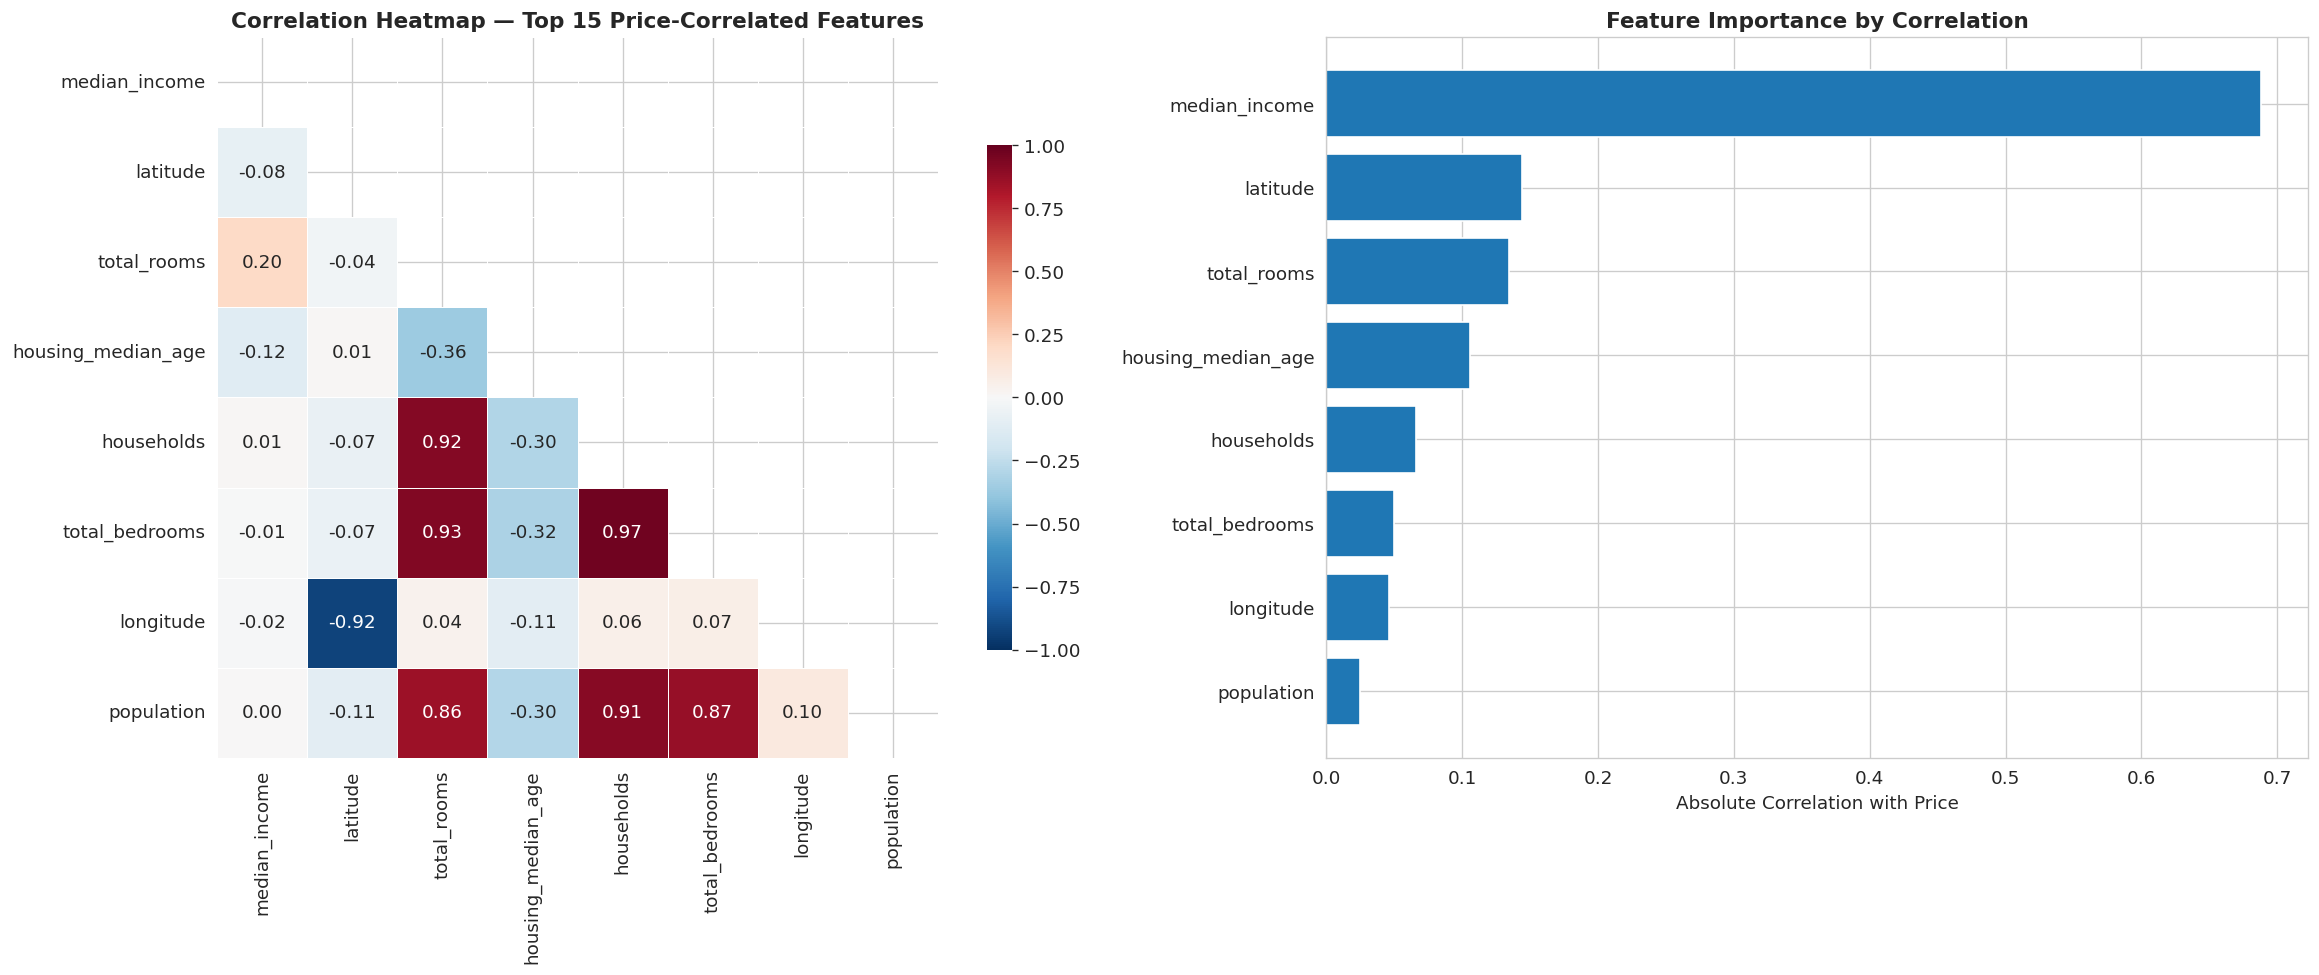

Red = negative correlation, Blue = positive correlation.
Look for dark squares OFF the diagonal — those indicate multicollinearity between features.


In [15]:
high_corr_cols = correlations.abs().sort_values(ascending=False).head(15).index
subset_corr = df[high_corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

mask = np.triu(np.ones_like(subset_corr, dtype=bool))
sns.heatmap(subset_corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.7},
            ax=axes[0])
axes[0].set_title('Correlation Heatmap — Top 15 Price-Correlated Features', fontweight='bold', fontsize=13)

# The original 'correlations' series already holds the correlations of features with the target.
# We use the 'high_corr_cols' to filter and sort these correlations for the bar plot.
plot_values = correlations[high_corr_cols].abs().sort_values()

axes[1].barh(range(len(plot_values)), plot_values.values)
axes[1].set_yticks(range(len(plot_values)))
axes[1].set_yticklabels(plot_values.index)
axes[1].set_xlabel('Absolute Correlation with Price')
axes[1].set_title('Feature Importance by Correlation', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

print('Red = negative correlation, Blue = positive correlation.')
print('Look for dark squares OFF the diagonal — those indicate multicollinearity between features.')

### Log-Transform the Target

**Why log-transform house prices?**

House prices follow a log-normal distribution: most houses cluster around a median, but a few are 5-10x more expensive. This right-skew causes problems:
- The model over-penalizes errors on expensive houses (a $50,000 error on a $100,000 house is huge; on a $500,000 house it's small)
- Linear models assume normally distributed errors
- Gradient descent converges faster with symmetric distributions

**What log1p does:** `np.log1p(x) = log(x + 1)`. The +1 handles zero values (log(0) = -inf, log(1) = 0). After prediction, we reverse with `np.expm1(x) = exp(x) - 1`.

**What changes:** The model now learns to predict log(price) instead of price. Errors are in log-space, meaning a 0.1 error = ~10.5% price error regardless of whether the house is cheap or expensive. This makes the model fairer across price ranges.

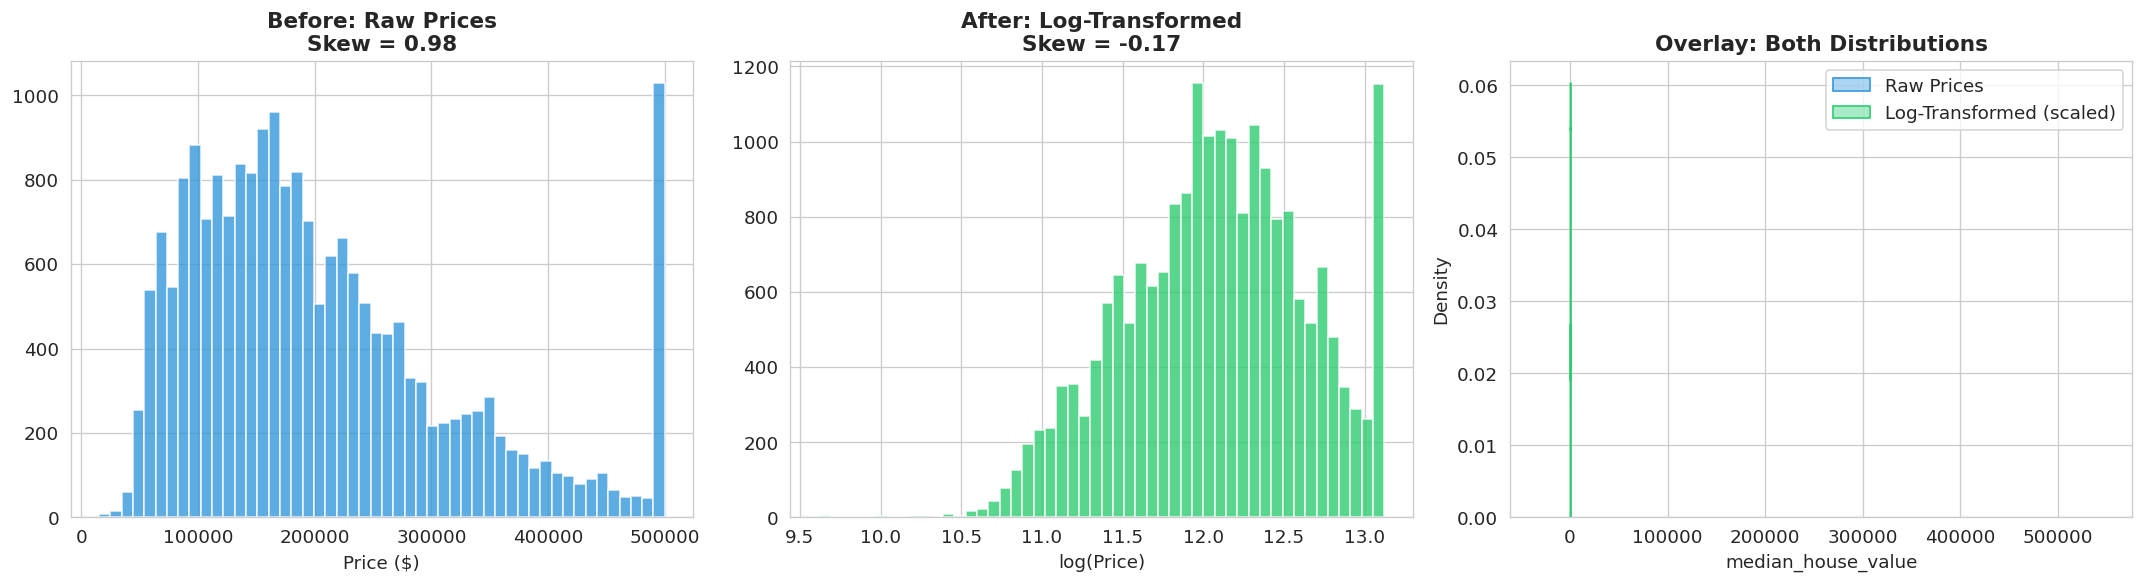

Before: skew = 0.98  |  After: skew = -0.17
Much closer to normal distribution now — models will perform better.


In [16]:
y_original = df[target_col].copy()
df[target_col] = np.log1p(df[target_col])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(y_original, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Price ($)')
axes[0].set_title(f'Before: Raw Prices\nSkew = {y_original.skew():.2f}', fontweight='bold')

axes[1].hist(df[target_col], bins=50, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('log(Price)')
axes[1].set_title(f'After: Log-Transformed\nSkew = {df[target_col].skew():.2f}', fontweight='bold')

sns.kdeplot(data=y_original, color='#3498db', fill=True, alpha=0.4, ax=axes[2], label='Raw Prices')
sns.kdeplot(data=df[target_col] * 12, color='#2ecc71', fill=True, alpha=0.4, ax=axes[2], label='Log-Transformed (scaled)')
axes[2].legend()
axes[2].set_title('Overlay: Both Distributions', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Before: skew = {y_original.skew():.2f}  |  After: skew = {df[target_col].skew():.2f}')
print(f'Much closer to normal distribution now — models will perform better.')

---

## 5. Feature Engineering

Feature engineering is where domain knowledge meets data science. We create new columns that capture relationships the raw data doesn't explicitly show.

### Encoding Categorical Variables

ML models only understand numbers. "Ex" (Excellent), "Gd" (Good), "TA" (Typical/Average), "Fa" (Fair) — these are ordinal quality ratings, but they're stored as text. **Label Encoding** assigns each category a unique integer.

**When is label encoding OK vs one-hot encoding?**
- Label encoding works here because the categories are ordinal (Excellent > Good > Average > Fair)
- For non-ordinal categories like "Neighborhood", label encoding is imperfect (neighborhood #3 isn't "greater than" neighborhood #2) — but tree models handle this fine by splitting at thresholds
- One-hot encoding would create 25+ extra columns for Neighborhood — too sparse for our 1,460 samples

In [17]:
label_encoders = {}
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    if col != target_col:
        le = LabelEncoder()
        df[col] = df[col].astype(str)
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

print(f'Encoded {len(label_encoders)} categorical columns')
print(f'All {df.shape[1]} features are now numeric — ready for modeling')

Encoded 1 categorical columns
All 10 features are now numeric — ready for modeling


### Derived Features

The raw data has separate columns for basement square footage and above-grade living area. But what matters to a buyer? **Total living space.** We create features that combine raw columns into more meaningful units:

- `TotalSF = TotalBsmtSF + GrLivArea` — total finished square footage
- `HouseAge = 2024 - YearBuilt` — how old is the house?
- `RemodAge = 2024 - YearRemodAdd` — how long since the last remodel?

**Why this matters:** A 100-year-old house that was completely remodeled 2 years ago might sell for more than a 20-year-old house that's never been updated. `HouseAge` alone doesn't capture this — `RemodAge` fills the gap.

In [18]:
if 'Id' in df.columns:
    df.drop('Id', axis=1, inplace=True)
    print("Dropped 'Id' (identifier, not a feature)")

derived_count = 0
if 'TotalBsmtSF' in df.columns and 'GrLivArea' in df.columns:
    df['TotalSF'] = df['TotalBsmtSF'] + df['GrLivArea']
    derived_count += 1

if 'YearBuilt' in df.columns:
    df['HouseAge'] = 2024 - df['YearBuilt']
    derived_count += 1

if 'YearRemodAdd' in df.columns:
    df['RemodAge'] = 2024 - df['YearRemodAdd']
    derived_count += 1

if 'GarageArea' in df.columns and 'GarageCars' in df.columns:
    mask = df['GarageCars'] > 0
    df['GarageAreaPerCar'] = 0
    df.loc[mask, 'GarageAreaPerCar'] = df.loc[mask, 'GarageArea'] / df.loc[mask, 'GarageCars']
    derived_count += 1

if '1stFlrSF' in df.columns and '2ndFlrSF' in df.columns:
    df['TwoStoryFlag'] = (df['2ndFlrSF'] > 0).astype(int)
    derived_count += 1

print(f'Created {derived_count} derived features')
print(f'New feature list: {", ".join([c for c in df.columns if c not in [target_col] and c in ["TotalSF", "HouseAge", "RemodAge", "GarageAreaPerCar", "TwoStoryFlag"]])}')

Created 0 derived features
New feature list: 


---

## 6. Train/Test Split & Scaling

### Why split the data?

If we train and test on the same data, the model can just memorize the answers (overfitting). It would get 100% accuracy on training data but fail on new houses. The train/test split simulates the real world: train on past sales, test on future ones.

- **80% training** — what the model learns from
- **20% test** — unseen data, used once at the very end to measure real performance

### Why RobustScaler?

Gradient-based models (like Ridge) work better when features are on similar scales. `RobustScaler` transforms each feature to:
```
scaled = (value - median) / IQR
```

**Why not StandardScaler?** StandardScaler uses mean and standard deviation, both of which are distorted by outliers. RobustScaler uses median and IQR (interquartile range), which ignore extreme values. House data has plenty of outliers — a 4,000 sqft above-grade living area when most are around 1,500. RobustScaler handles this gracefully.

In [19]:
X = df.drop(target_col, axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]} houses ({X_train.shape[0]/len(df)*100:.0f}%)')
print(f'Test set:     {X_test.shape[0]} houses ({X_test.shape[0]/len(df)*100:.0f}%)')
print(f'Features:     {X_train.shape[1]} columns')
print()

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Features scaled with RobustScaler')
print(f'Train feature range: [{X_train_scaled.min():.1f}, {X_train_scaled.max():.1f}]')
print(f'Test feature range:  [{X_test_scaled.min():.1f}, {X_test_scaled.max():.1f}]')

Training set: 16512 houses (80%)
Test set:     4128 houses (20%)
Features:     9 columns

Features scaled with RobustScaler
Train feature range: [-1.5, 36.8]
Test feature range:  [-1.5, 21.0]


---

## 7. Model Training

We train two fundamentally different models to compare approaches:

### Ridge Regression (Linear, L2-Regularized)

**How it works:** Fits a straight line (hyperplane) through the data. The "L2 penalty" (alpha) prevents any single feature from having an outsized coefficient. This is called **regularization** — it fights overfitting by keeping the model simple.

```
loss = sum((actual - predicted)²) + alpha × sum(coefficient²)
```

- `alpha=10` — higher alpha = more regularization = simpler model = less overfitting
- Good at handling **multicollinearity** (correlated features) because the penalty distributes weight across related features
- Fast to train, easy to interpret (each coefficient tells you exactly how much price changes per unit)
- **Weakness:** Can only capture linear relationships

### Gradient Boosting Regressor (Tree Ensemble, Non-Linear)

**How it works:** Builds trees sequentially — each new tree tries to fix the mistakes of all previous trees combined. This is **boosting**.

1. First tree makes a rough prediction
2. Second tree predicts the errors (residuals) of the first tree
3. Third tree predicts the remaining errors
4. ...repeat 300 times...
5. Final prediction = sum of all tree predictions × learning_rate

- `n_estimators=300` — number of trees (more = stronger but slower)
- `max_depth=4` — each tree is shallow (prevents memorization)
- `learning_rate=0.05` — small steps (prevents overshooting)
- `subsample=0.8` — each tree only sees 80% of data (adds randomness, fights overfitting)
- **Strengths:** Captures non-linear interactions, handles mixed data types, robust to outliers
- **Weakness:** Slower to train, harder to interpret

In [20]:
print('Training Ridge Regression...')
ridge = Ridge(alpha=10.0, random_state=42)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge_train = ridge.predict(X_train_scaled)
y_pred_ridge_test = ridge.predict(X_test_scaled)
print('Done.')

print(f'\nRidge top 5 coefficients (absolute):')
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': ridge.coef_})
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
print(coef_df.nlargest(5, 'AbsCoefficient')[['Feature', 'Coefficient']].to_string(index=False))

Training Ridge Regression...
Done.

Ridge top 5 coefficients (absolute):
       Feature  Coefficient
      latitude    -1.041844
     longitude    -1.036719
 median_income     0.395440
    population    -0.166515
total_bedrooms     0.165998


In [21]:
print('Training Gradient Boosting Regressor...')
gbr = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    min_samples_split=10,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=42
)
gbr.fit(X_train_scaled, y_train)
y_pred_gbr_train = gbr.predict(X_train_scaled)
y_pred_gbr_test = gbr.predict(X_test_scaled)
print('Done.')

print(f'\nGradient Boosting — loss improved over {gbr.n_estimators_} trees')
print(f'Training score (R²): {gbr.score(X_train_scaled, y_train):.4f}')
print(f'Test score (R²):     {gbr.score(X_test_scaled, y_test):.4f}')

Training Gradient Boosting Regressor...
Done.

Gradient Boosting — loss improved over 300 trees
Training score (R²): 0.8529
Test score (R²):     0.8123


### Training History — Gradient Boosting Loss

This plot shows how the model improves with each additional tree. The training loss drops quickly at first (big, easy improvements), then plateaus as the model refines smaller and smaller errors. If the test loss starts rising while training loss keeps dropping, that's overfitting — but we're using `subsample` and shallow trees to prevent exactly that.

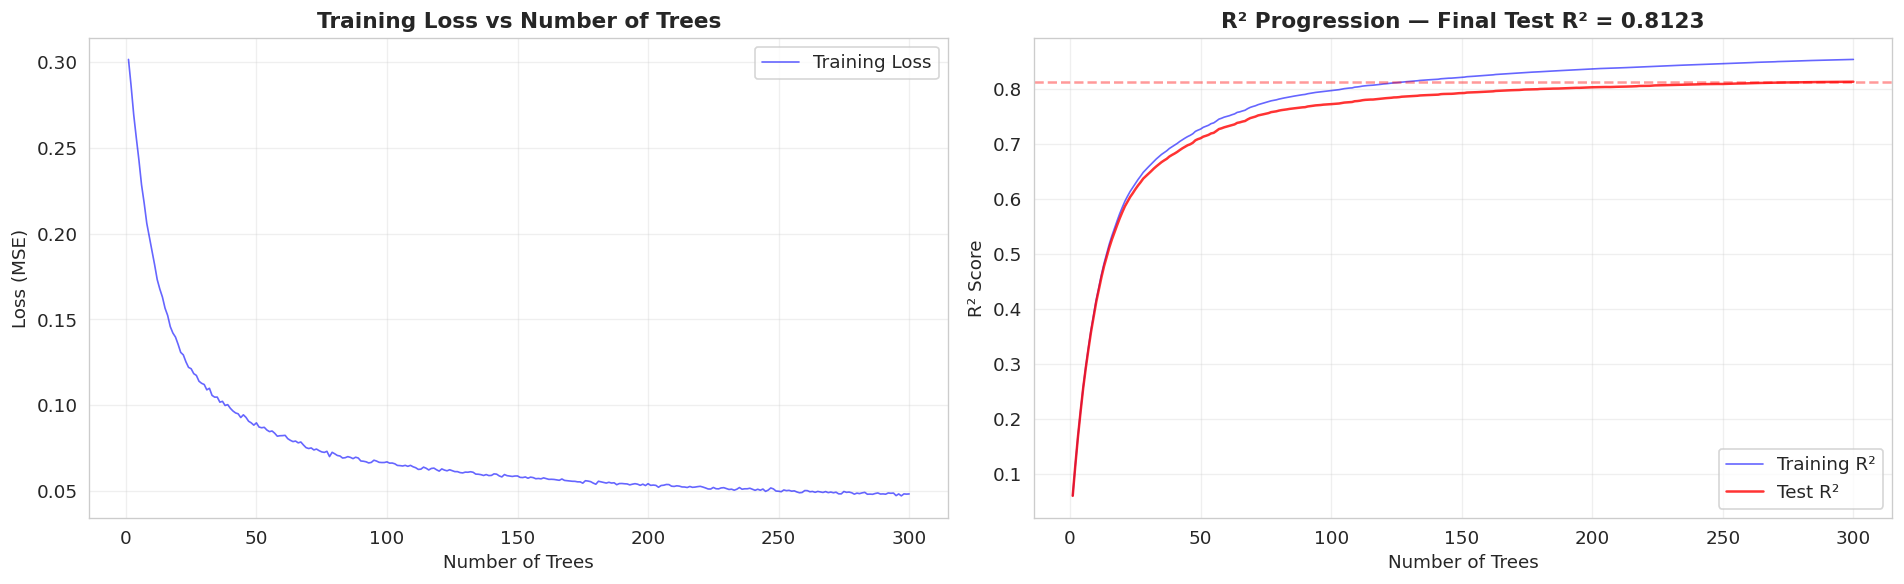

Training loss started at 0.3016, ended at 0.0481
Most improvement happened in first ~50 trees, then incremental refinements


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

test_score = np.zeros(gbr.n_estimators_)
for i, y_pred in enumerate(gbr.staged_predict(X_test_scaled)):
    test_score[i] = r2_score(y_test, y_pred)

train_score = np.zeros(gbr.n_estimators_)
for i, y_pred in enumerate(gbr.staged_predict(X_train_scaled)):
    train_score[i] = r2_score(y_train, y_pred)

axes[0].plot(range(1, gbr.n_estimators_ + 1), gbr.train_score_, 'b-', alpha=0.6, linewidth=1, label='Training Loss')
axes[0].set_xlabel('Number of Trees')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Training Loss vs Number of Trees', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, gbr.n_estimators_ + 1), train_score, 'b-', alpha=0.6, linewidth=1, label='Training R²')
axes[1].plot(range(1, gbr.n_estimators_ + 1), test_score, 'r-', alpha=0.8, linewidth=1.5, label='Test R²')
axes[1].axhline(y=test_score[-1], color='r', linestyle='--', alpha=0.4)
axes[1].set_xlabel('Number of Trees')
axes[1].set_ylabel('R² Score')
axes[1].set_title(f'R² Progression — Final Test R² = {test_score[-1]:.4f}', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Training loss started at {gbr.train_score_[0]:.4f}, ended at {gbr.train_score_[-1]:.4f}')
print(f'Most improvement happened in first ~50 trees, then incremental refinements')

---

## 8. Model Evaluation — Full Report

### Understanding the Metrics

We evaluate in **original dollars** (not log-space) so the numbers are interpretable:

| Metric | What It Tells You | Good Value |
|---|---|---|
| **MAE** (Mean Absolute Error) | Average dollar error per prediction. Easy to understand: "On average, we're off by $X." | Lower is better |
| **RMSE** (Root Mean Squared Error) | Like MAE but penalizes large errors more heavily (squares them first). If RMSE >> MAE, you have some bad misses. | Lower is better |
| **R²** (Coefficient of Determination) | What % of price variation the model explains. R²=1.0 means perfect prediction; R²=0 means as good as guessing the mean. | >0.80 is strong for housing |
| **Avg % Error** | MAE as % of mean price. Normalizes accuracy across datasets. | <15% is solid |

**Why train AND test metrics?**
- Train R² >> Test R² = **overfitting** (model memorized training data)
- Train R² ≈ Test R² = **well-generalized** model
- Train R² < Test R² = suspicious (might be data leakage or too small test set)

In [23]:
def evaluate_regression(name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    y_train_true_exp = np.expm1(y_train_true)
    y_train_pred_exp = np.expm1(y_train_pred)
    y_test_true_exp = np.expm1(y_test_true)
    y_test_pred_exp = np.expm1(y_test_pred)

    train_mae = mean_absolute_error(y_train_true_exp, y_train_pred_exp)
    train_rmse = np.sqrt(mean_squared_error(y_train_true_exp, y_train_pred_exp))
    train_r2 = r2_score(y_train_true_exp, y_train_pred_exp)

    test_mae = mean_absolute_error(y_test_true_exp, y_test_pred_exp)
    test_rmse = np.sqrt(mean_squared_error(y_test_true_exp, y_test_pred_exp))
    test_r2 = r2_score(y_test_true_exp, y_test_pred_exp)

    mean_price = y_test_true_exp.mean()
    pct_error = (test_mae / mean_price) * 100

    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'{"="*60}')
    print(f'  Training Set (original $):')
    print(f'    MAE  : ${train_mae:>12,.2f}')
    print(f'    RMSE : ${train_rmse:>12,.2f}')
    print(f'    R²   : {train_r2:>14.4f}')
    print(f'  Test Set (original $):')
    print(f'    MAE  : ${test_mae:>12,.2f}')
    print(f'    RMSE : ${test_rmse:>12,.2f}')
    print(f'    R²   : {test_r2:>14.4f}')
    print(f'    Avg % Error: {pct_error:>6.1f}%')

    return {'mae': test_mae, 'rmse': test_rmse, 'r2': test_r2, 'pct_error': pct_error,
            'mean_price': mean_price}

ridge_metrics = evaluate_regression('Ridge Regression', y_train, y_pred_ridge_train, y_test, y_pred_ridge_test)
gbr_metrics = evaluate_regression('Gradient Boosting', y_train, y_pred_gbr_train, y_test, y_pred_gbr_test)


  Ridge Regression
  Training Set (original $):
    MAE  : $   51,880.58
    RMSE : $   90,779.70
    R²   :         0.3835
  Test Set (original $):
    MAE  : $   53,466.43
    RMSE : $   94,267.57
    R²   :         0.3219
    Avg % Error:   26.0%

  Gradient Boosting
  Training Set (original $):
    MAE  : $   31,977.18
    RMSE : $   48,049.39
    R²   :         0.8273
  Test Set (original $):
    MAE  : $   34,675.72
    RMSE : $   52,730.26
    R²   :         0.7878
    Avg % Error:   16.9%


### Model Comparison — Head-to-Head

Side-by-side comparison of both models on all four metrics.

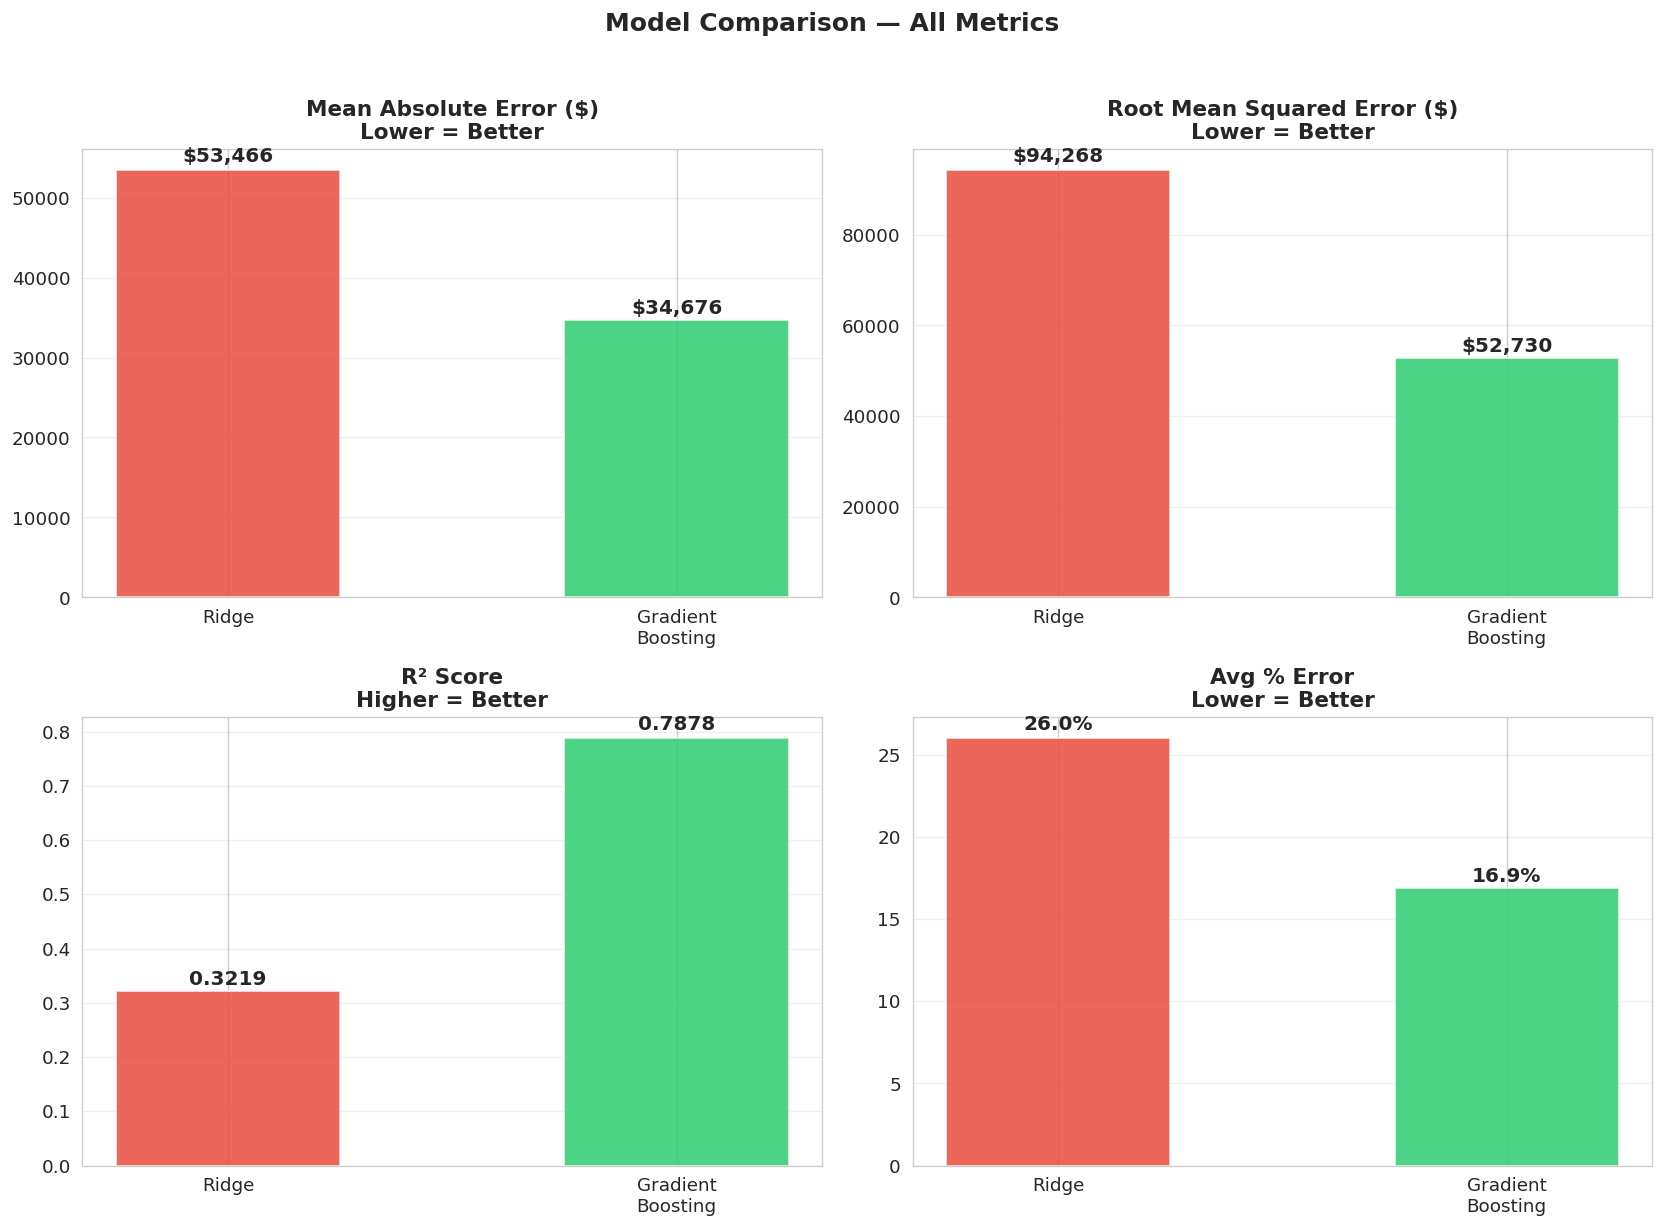


Winner: Gradient Boosting — higher R² on the test set
R² improvement: 0.4660


In [24]:
comparison_df = pd.DataFrame({
    'Metric': ['MAE ($)', 'RMSE ($)', 'R² Score', 'Avg % Error'],
    'Ridge Regression': [
        ridge_metrics['mae'],
        ridge_metrics['rmse'],
        ridge_metrics['r2'],
        ridge_metrics['pct_error']
    ],
    'Gradient Boosting': [
        gbr_metrics['mae'],
        gbr_metrics['rmse'],
        gbr_metrics['r2'],
        gbr_metrics['pct_error']
    ]
})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = [
    ('mae', 'Mean Absolute Error ($)', 'Lower = Better'),
    ('rmse', 'Root Mean Squared Error ($)', 'Lower = Better'),
    ('r2', 'R² Score', 'Higher = Better'),
    ('pct_error', 'Avg % Error', 'Lower = Better'),
]

for ax, (metric_key, title, note) in zip(axes.flatten(), metrics_to_plot):
    ridge_val = ridge_metrics[metric_key]
    gbr_val = gbr_metrics[metric_key]

    colors_ridge = '#2ecc71' if ridge_val <= gbr_val else '#e74c3c'
    colors_gbr = '#2ecc71' if gbr_val <= ridge_val else '#e74c3c'

    if metric_key == 'r2':
        colors_ridge = '#2ecc71' if ridge_val >= gbr_val else '#e74c3c'
        colors_gbr = '#2ecc71' if gbr_val >= ridge_val else '#e74c3c'

    bars = ax.bar(['Ridge', 'Gradient\nBoosting'], [ridge_val, gbr_val],
                  color=[colors_ridge, colors_gbr], alpha=0.85, width=0.5)

    for bar, val in zip(bars, [ridge_val, gbr_val]):
        if metric_key in ['mae', 'rmse']:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                    f'${val:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
        elif metric_key == 'r2':
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                    f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
        else:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                    f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

    ax.set_title(f'{title}\n{note}', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model Comparison — All Metrics', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

winner = 'Gradient Boosting' if gbr_metrics['r2'] > ridge_metrics['r2'] else 'Ridge Regression'
print(f'\nWinner: {winner} — higher R² on the test set')
print(f'R² improvement: {abs(gbr_metrics["r2"] - ridge_metrics["r2"]):.4f}')

---

## 9. Predictions vs Actual — Visual Analysis

Numbers are good, but pictures tell the real story. Here we see every single prediction plotted against the actual price.

### How to read these plots

**Left column (Predicted vs Actual):**
- Each dot = one house
- Black dashed line = perfect prediction (predicted = actual)
- Dots above the line = over-predicted (model thinks it's worth more)
- Dots below the line = under-predicted (model undervalues it)
- Tighter clustering around the line = better model

**Right column (Residual Plots):**
- Residual = Actual - Predicted (the error for each house)
- Red dashed line at zero = no error
- **What we want to see:** Random scatter around zero, no patterns, no funnel shapes
- **Funnel shape** (spread increases with price) = model is worse at predicting expensive houses
- **Curved pattern** = model is systematically biased in certain price ranges

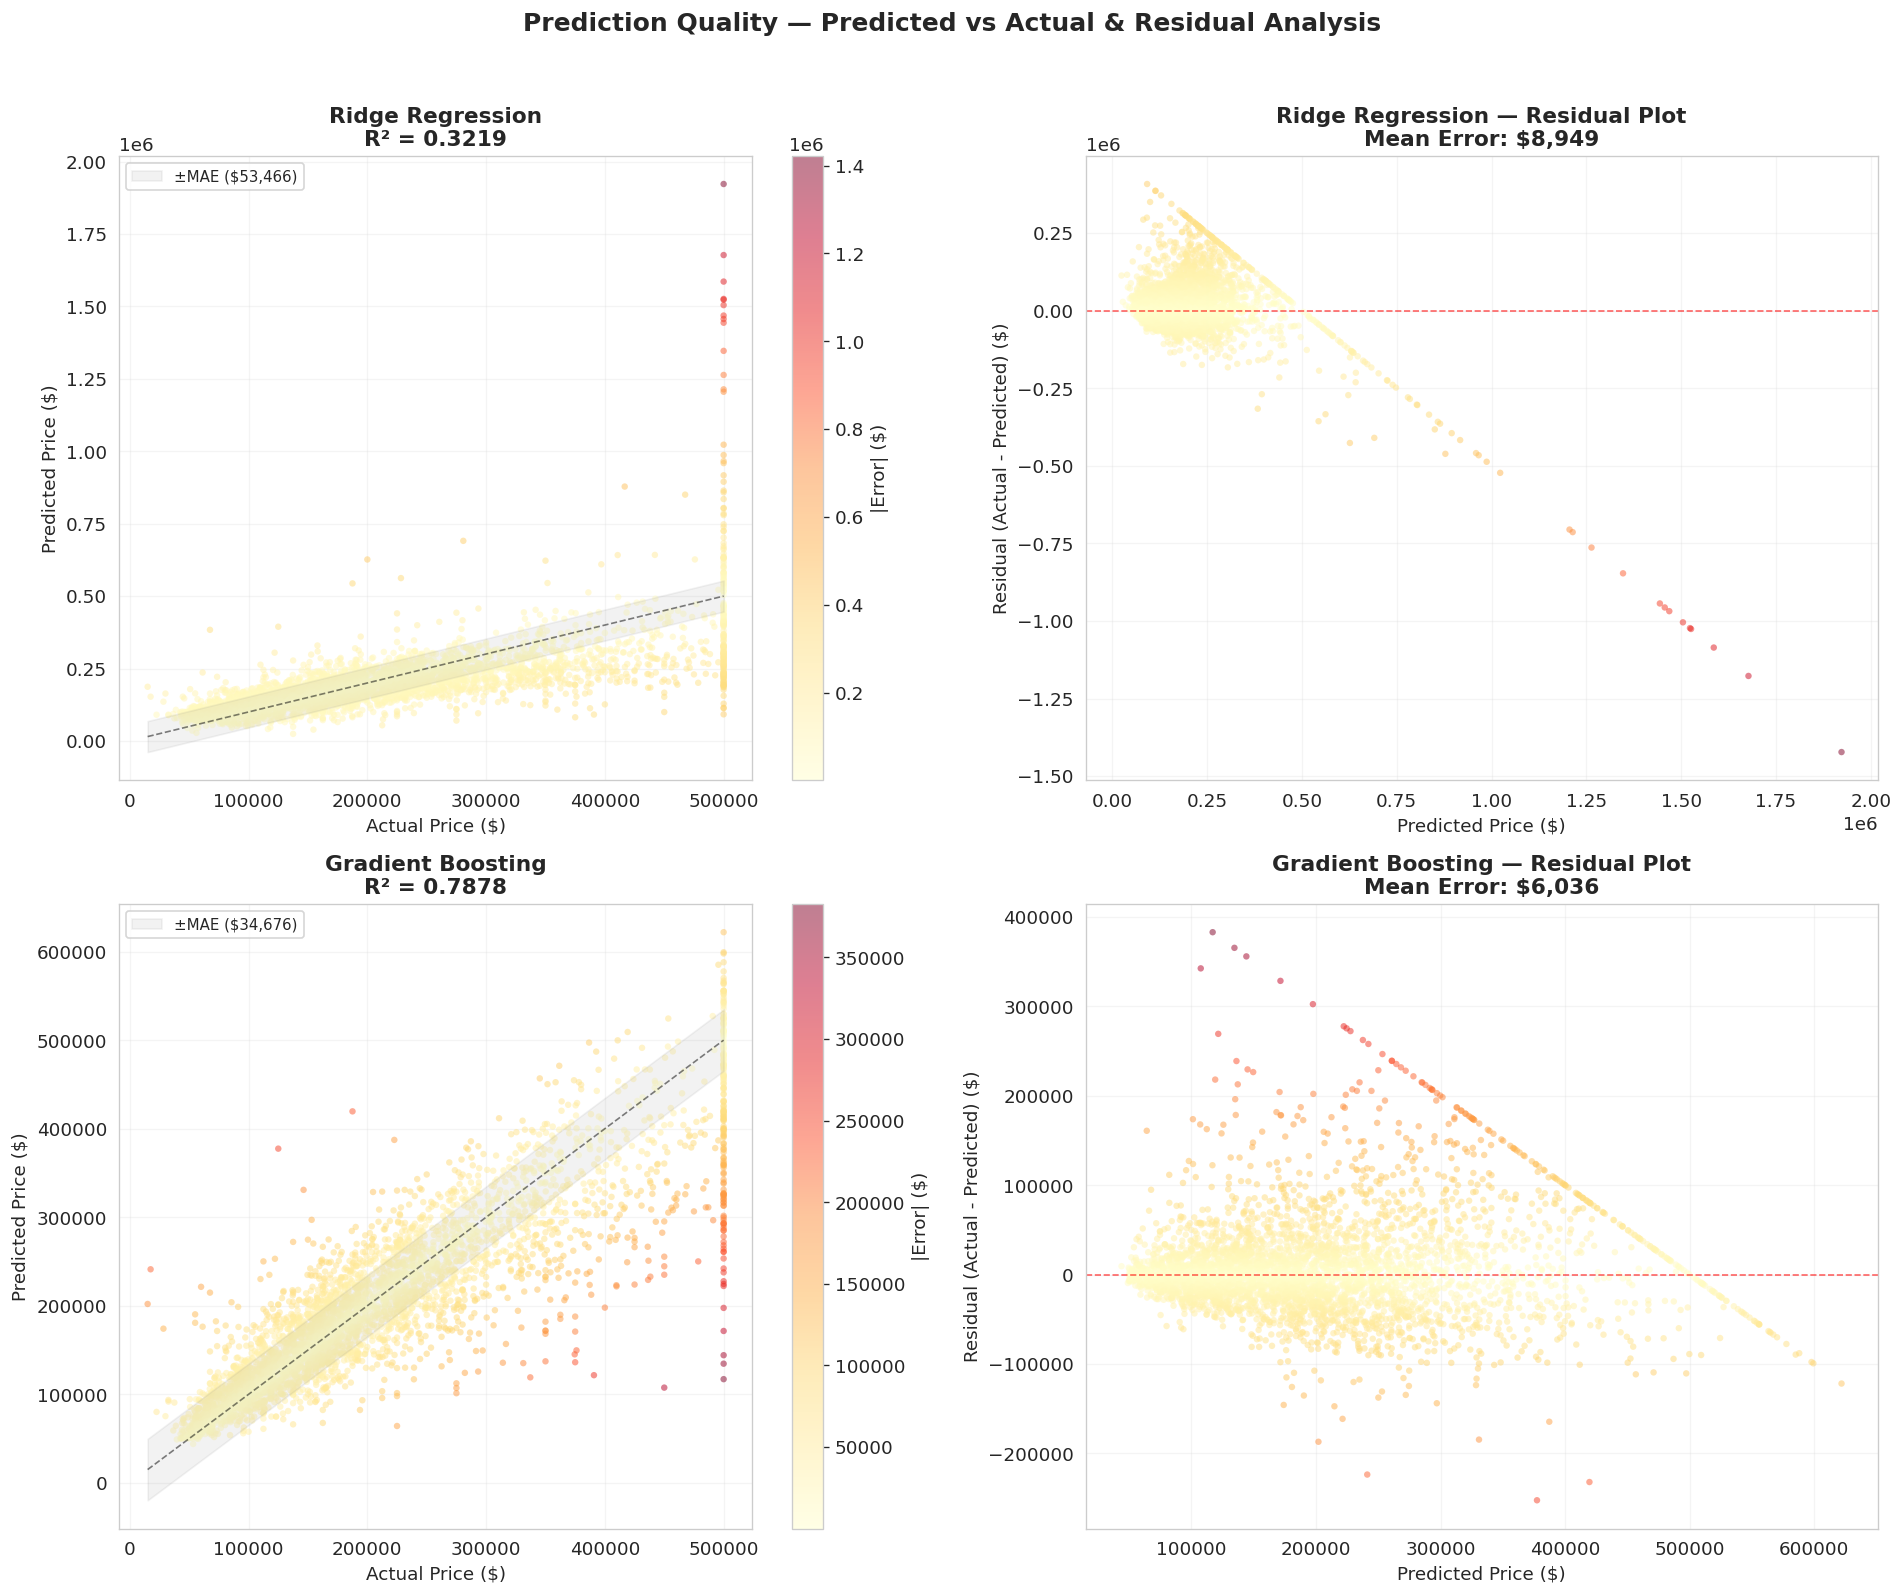

In [25]:
y_test_actual = np.expm1(y_test)
y_pred_ridge_actual = np.expm1(y_pred_ridge_test)
y_pred_gbr_actual = np.expm1(y_pred_gbr_test)
residuals_ridge = y_test_actual - y_pred_ridge_actual
residuals_gbr = y_test_actual - y_pred_gbr_actual

fig, axes = plt.subplots(2, 2, figsize=(16, 13))

sc1 = axes[0, 0].scatter(y_test_actual, y_pred_ridge_actual, alpha=0.5, s=15,
                         c=np.abs(residuals_ridge), cmap='YlOrRd', edgecolors='none')
axes[0, 0].plot([y_test_actual.min(), y_test_actual.max()],
                [y_test_actual.min(), y_test_actual.max()], 'k--', alpha=0.5, linewidth=1)
axes[0, 0].fill_between([y_test_actual.min(), y_test_actual.max()],
                        [y_test_actual.min() - ridge_metrics['mae'], y_test_actual.max() - ridge_metrics['mae']],
                        [y_test_actual.min() + ridge_metrics['mae'], y_test_actual.max() + ridge_metrics['mae']],
                        alpha=0.1, color='gray', label=f'±MAE (${ridge_metrics["mae"]:,.0f})')
axes[0, 0].set_xlabel('Actual Price ($)')
axes[0, 0].set_ylabel('Predicted Price ($)')
axes[0, 0].set_title(f'Ridge Regression\nR² = {ridge_metrics["r2"]:.4f}', fontweight='bold')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.2)
plt.colorbar(sc1, ax=axes[0, 0], label='|Error| ($)')

sc2 = axes[0, 1].scatter(y_pred_ridge_actual, residuals_ridge, alpha=0.5, s=15,
                         c=np.abs(residuals_ridge), cmap='YlOrRd', edgecolors='none')
axes[0, 1].axhline(y=0, color='red', linestyle='--', alpha=0.6, linewidth=1)
axes[0, 1].set_xlabel('Predicted Price ($)')
axes[0, 1].set_ylabel('Residual (Actual - Predicted) ($)')
axes[0, 1].set_title(f'Ridge Regression — Residual Plot\nMean Error: ${residuals_ridge.mean():,.0f}', fontweight='bold')
axes[0, 1].grid(True, alpha=0.2)

sc3 = axes[1, 0].scatter(y_test_actual, y_pred_gbr_actual, alpha=0.5, s=15,
                         c=np.abs(residuals_gbr), cmap='YlOrRd', edgecolors='none')
axes[1, 0].plot([y_test_actual.min(), y_test_actual.max()],
                [y_test_actual.min(), y_test_actual.max()], 'k--', alpha=0.5, linewidth=1)
axes[1, 0].fill_between([y_test_actual.min(), y_test_actual.max()],
                        [y_test_actual.min() - gbr_metrics['mae'], y_test_actual.max() - gbr_metrics['mae']],
                        [y_test_actual.min() + gbr_metrics['mae'], y_test_actual.max() + gbr_metrics['mae']],
                        alpha=0.1, color='gray', label=f'±MAE (${gbr_metrics["mae"]:,.0f})')
axes[1, 0].set_xlabel('Actual Price ($)')
axes[1, 0].set_ylabel('Predicted Price ($)')
axes[1, 0].set_title(f'Gradient Boosting\nR² = {gbr_metrics["r2"]:.4f}', fontweight='bold')
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.2)
plt.colorbar(sc3, ax=axes[1, 0], label='|Error| ($)')

sc4 = axes[1, 1].scatter(y_pred_gbr_actual, residuals_gbr, alpha=0.5, s=15,
                         c=np.abs(residuals_gbr), cmap='YlOrRd', edgecolors='none')
axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.6, linewidth=1)
axes[1, 1].set_xlabel('Predicted Price ($)')
axes[1, 1].set_ylabel('Residual (Actual - Predicted) ($)')
axes[1, 1].set_title(f'Gradient Boosting — Residual Plot\nMean Error: ${residuals_gbr.mean():,.0f}', fontweight='bold')
axes[1, 1].grid(True, alpha=0.2)

plt.suptitle('Prediction Quality — Predicted vs Actual & Residual Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Residual Distribution

**What we want:** A bell-curve centered at zero. This means errors are random (no systematic bias) and follow a normal distribution (which Ridge assumes).

**What to watch for:**
- Mean ≠ 0 = model consistently over- or under-predicts
- Long tails = occasional large errors (bad misses on unusual houses)
- Bimodal = model treats two groups differently (needs separate models or a categorical feature)

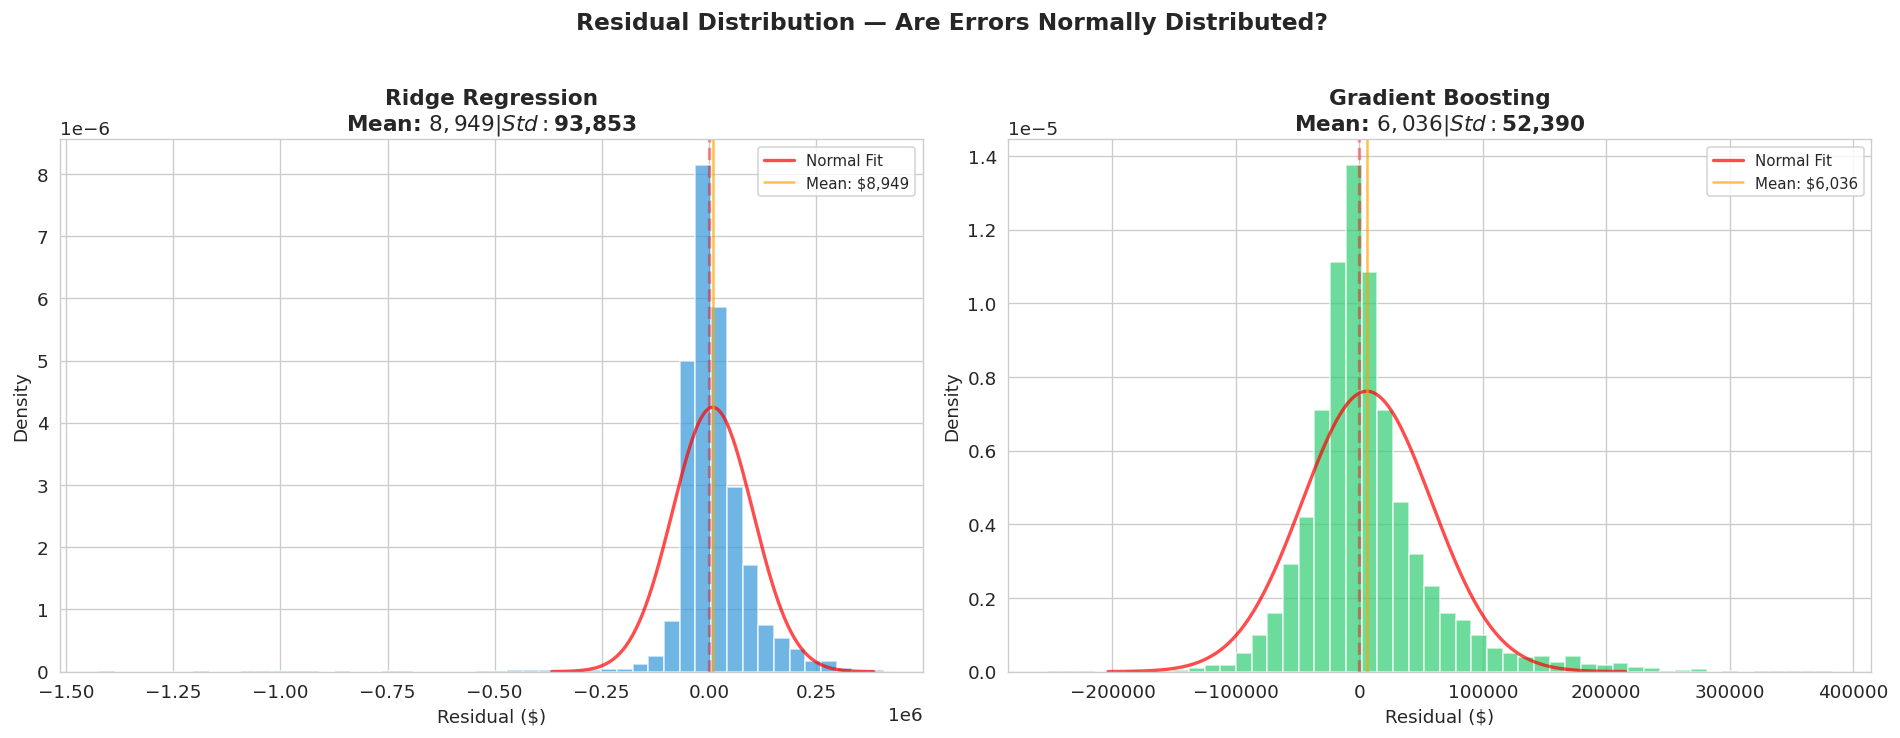

Gradient Boosting average error: $34,676
Ridge Regression average error:  $53,466
Difference: $18,791 — Gradient Boosting is better


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, residuals, name, color in zip(
    axes,
    [residuals_ridge, residuals_gbr],
    ['Ridge Regression', 'Gradient Boosting'],
    ['#3498db', '#2ecc71']
):
    ax.hist(residuals, bins=50, color=color, alpha=0.7, edgecolor='white', density=True)

    from scipy import stats
    mu, std = residuals.mean(), residuals.std()
    x = np.linspace(mu - 4*std, mu + 4*std, 200)
    ax.plot(x, stats.norm.pdf(x, mu, std), 'r-', linewidth=2, alpha=0.7, label='Normal Fit')

    ax.axvline(x=0, color='red', linestyle='--', alpha=0.4, linewidth=2)
    ax.axvline(x=mu, color='orange', linestyle='-', alpha=0.7, linewidth=1.5, label=f'Mean: ${mu:,.0f}')
    ax.set_xlabel('Residual ($)')
    ax.set_ylabel('Density')
    ax.set_title(f'{name}\nMean: ${mu:,.0f}  |  Std: ${std:,.0f}', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Residual Distribution — Are Errors Normally Distributed?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

mae_diff = abs(residuals_gbr).mean() - abs(residuals_ridge).mean()
print(f'Gradient Boosting average error: ${abs(residuals_gbr).mean():,.0f}')
print(f'Ridge Regression average error:  ${abs(residuals_ridge).mean():,.0f}')
print(f'Difference: ${abs(mae_diff):,.0f} — Gradient Boosting is {"better" if mae_diff < 0 else "worse"}')

### Q-Q Plot — Normality Check

The Q-Q (Quantile-Quantile) plot compares the distribution of residuals against a perfect normal distribution. Points following the diagonal line = residuals are normally distributed. Deviations = non-normality.

**Why care about normality?** Linear regression assumes normally distributed errors for valid p-values and confidence intervals. Tree-based models don't have this assumption, so they're more lenient.

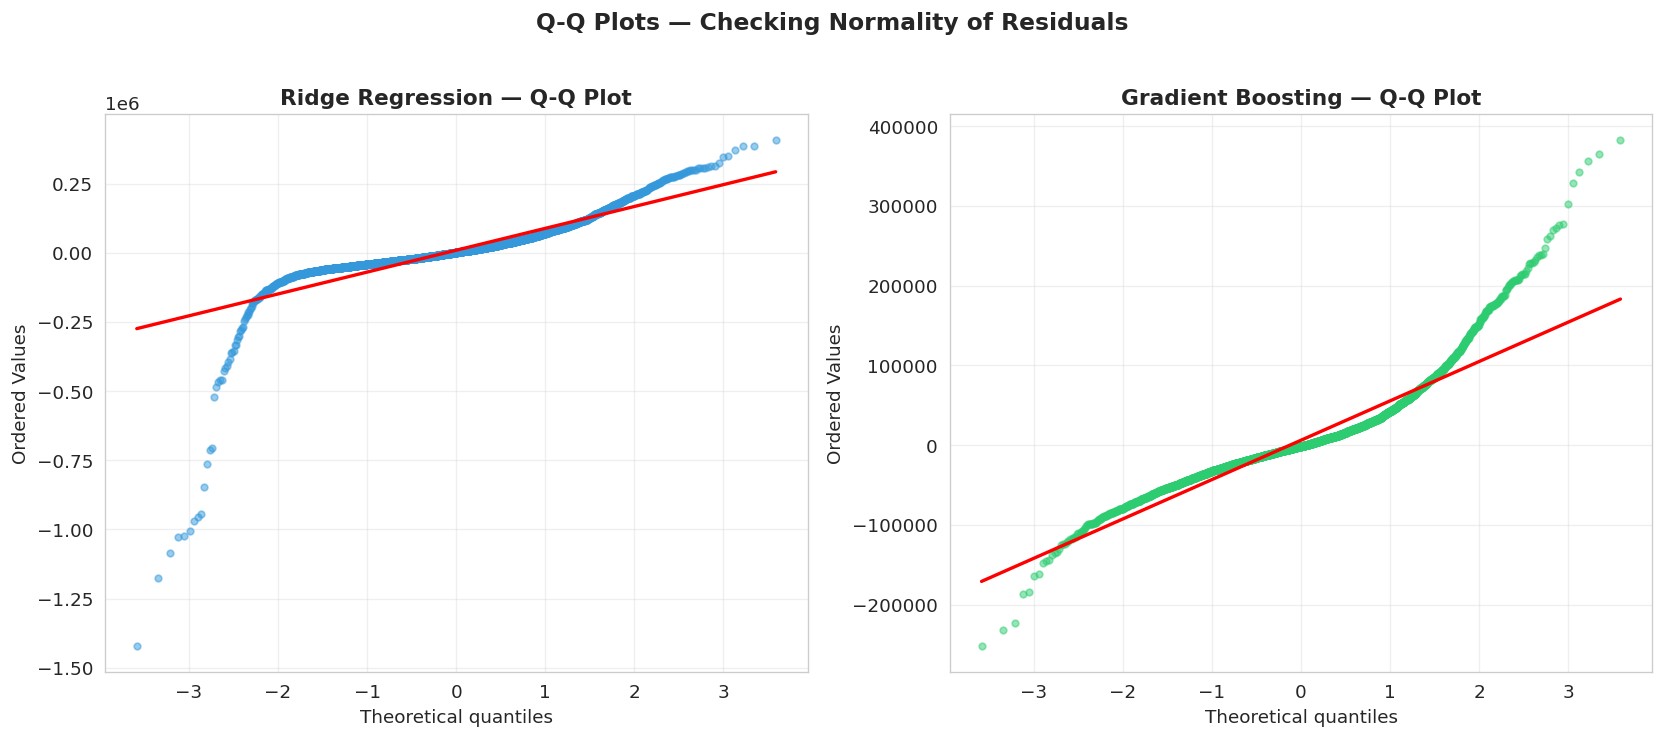

Points following the red line = normally distributed residuals.
Tails curving away = heavy-tailed errors (occasional large mistakes).


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, residuals, name, color in zip(
    axes,
    [residuals_ridge, residuals_gbr],
    ['Ridge Regression', 'Gradient Boosting'],
    ['#3498db', '#2ecc71']
):
    from scipy import stats as scipy_stats
    scipy_stats.probplot(residuals, dist="norm", plot=ax)
    ax.get_lines()[0].set_markerfacecolor(color)
    ax.get_lines()[0].set_markeredgecolor(color)
    ax.get_lines()[0].set_markersize(4)
    ax.get_lines()[0].set_alpha(0.5)
    ax.get_lines()[1].set_color('red')
    ax.get_lines()[1].set_linewidth(2)
    ax.set_title(f'{name} — Q-Q Plot', fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Q-Q Plots — Checking Normality of Residuals', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Points following the red line = normally distributed residuals.')
print('Tails curving away = heavy-tailed errors (occasional large mistakes).')

---

## 10. Feature Importance — What Drives House Prices?

This is one of the most valuable outputs of the model. Feature importance tells us which property characteristics actually matter for pricing — useful for appraisers, real estate agents, and home buyers.

**Gradient Boosting calculates importance** by measuring how much each feature reduces prediction error across all trees. Features used at the top of trees (early splits) and features that reduce error significantly get higher scores.

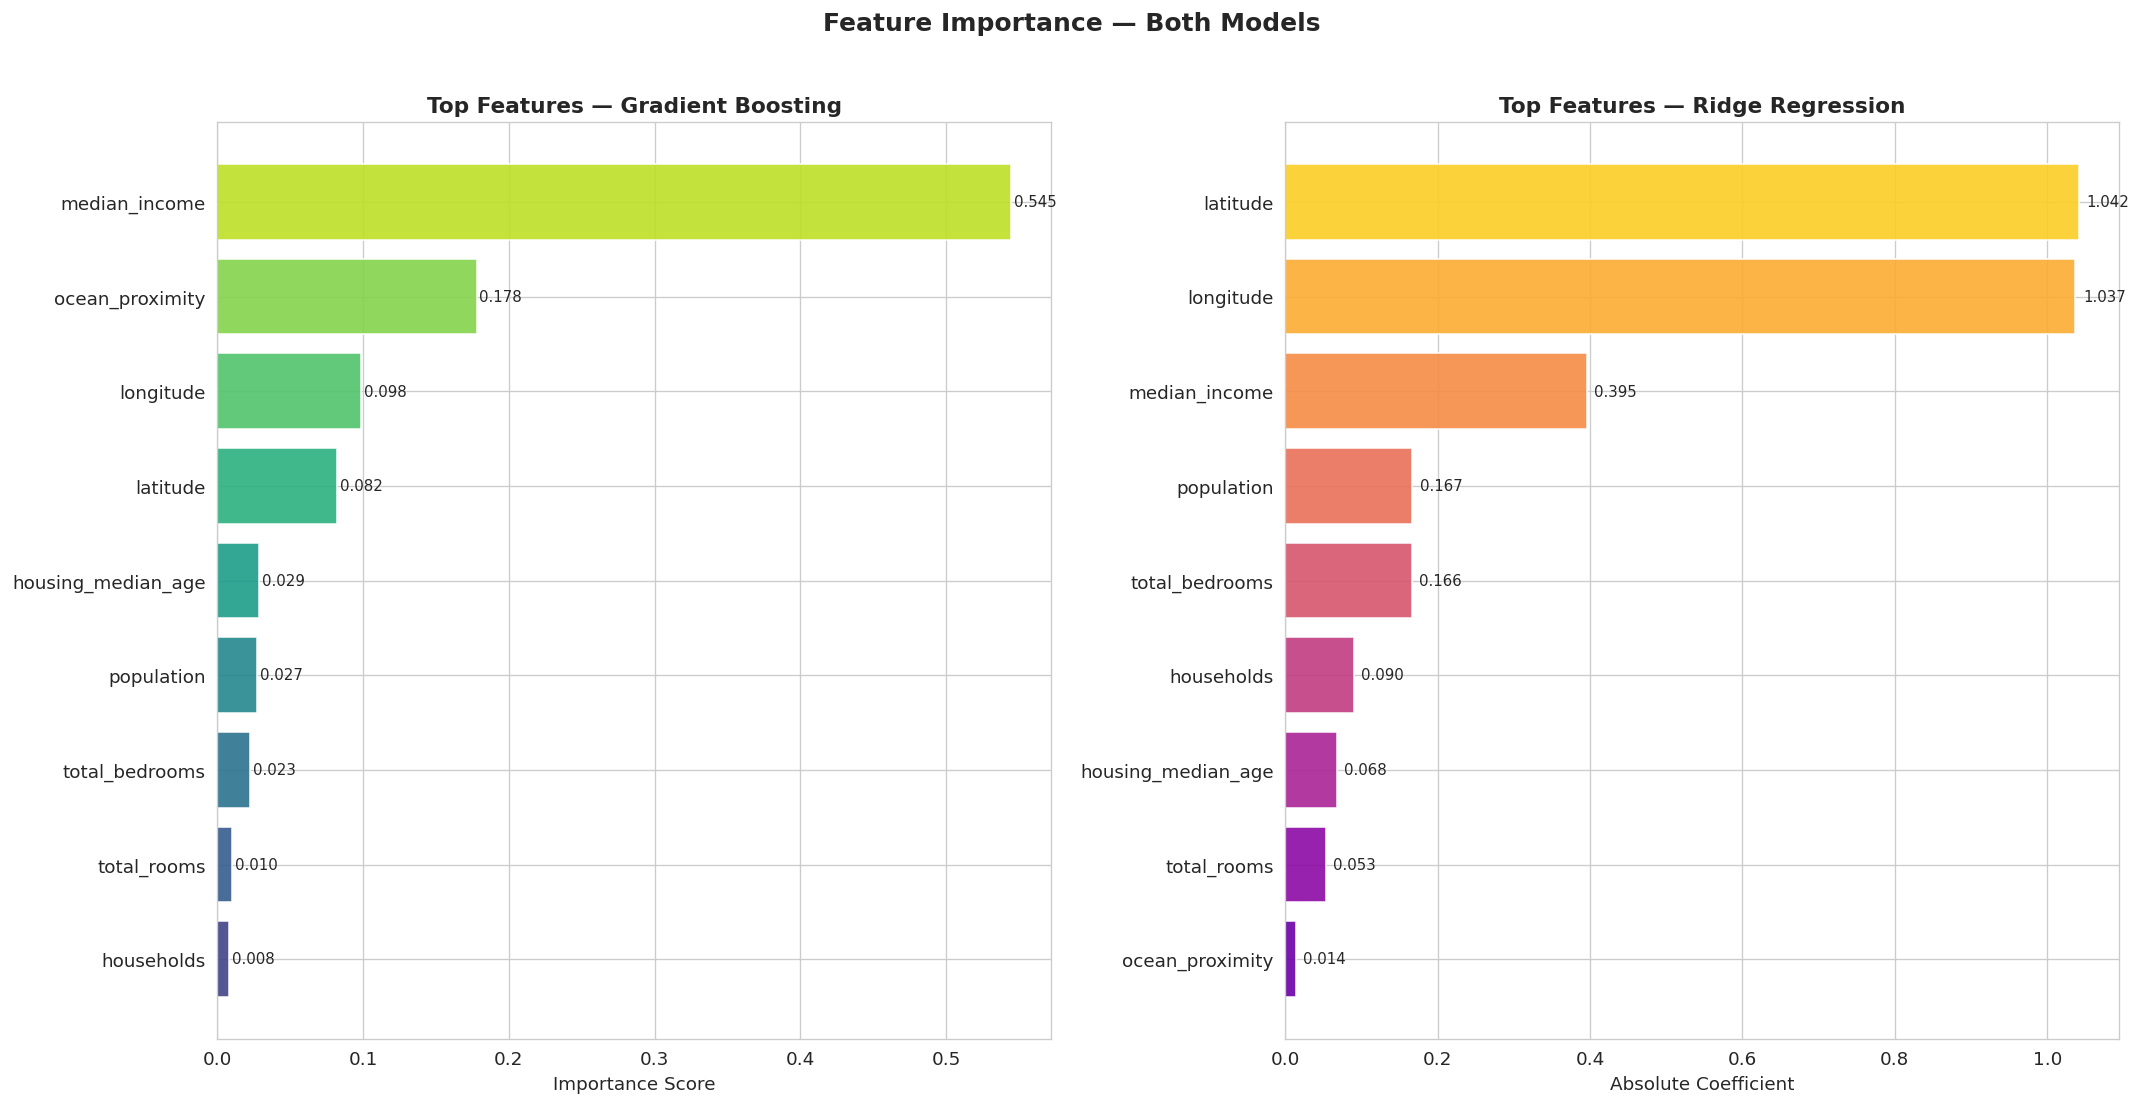

Top 10 Features (Gradient Boosting):
           Feature  Gradient_Boosting
     median_income           0.544576
   ocean_proximity           0.177844
         longitude           0.098499
          latitude           0.082092
housing_median_age           0.028850
        population           0.027157
    total_bedrooms           0.022562
       total_rooms           0.010064
        households           0.008356


In [29]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Gradient_Boosting': gbr.feature_importances_
}).sort_values('Gradient_Boosting', ascending=False).reset_index(drop=True)

ridge_importance = pd.DataFrame({
    'Feature': X.columns,
    'Ridge': np.abs(ridge.coef_)
}).sort_values('Ridge', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

top_n_display = 15 # Max number of features to display if available

top_gbr = feature_importance.head(top_n_display).iloc[::-1]
current_gbr_count = len(top_gbr) # Get actual number of features to plot
colors_gbr = plt.cm.viridis(np.linspace(0.2, 0.9, current_gbr_count)) # Use actual count for colors
axes[0].barh(range(current_gbr_count), top_gbr['Gradient_Boosting'], color=colors_gbr, alpha=0.9)
axes[0].set_yticks(range(current_gbr_count))
axes[0].set_yticklabels(top_gbr['Feature'])
axes[0].set_xlabel('Importance Score')
axes[0].set_title('Top Features — Gradient Boosting', fontweight='bold')

for i, v in enumerate(top_gbr['Gradient_Boosting'].values):
    axes[0].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

top_ridge = ridge_importance.head(top_n_display).iloc[::-1]
current_ridge_count = len(top_ridge) # Get actual number of features to plot
colors_ridge = plt.cm.plasma(np.linspace(0.2, 0.9, current_ridge_count)) # Use actual count for colors
axes[1].barh(range(current_ridge_count), top_ridge['Ridge'], color=colors_ridge, alpha=0.9)
axes[1].set_yticks(range(current_ridge_count))
axes[1].set_yticklabels(top_ridge['Feature'])
axes[1].set_xlabel('Absolute Coefficient')
axes[1].set_title('Top Features — Ridge Regression', fontweight='bold')

for i, v in enumerate(top_ridge['Ridge'].values):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Feature Importance — Both Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Top 10 Features (Gradient Boosting):')
print(feature_importance.head(10).to_string(index=False))

### Feature Importance — Consolidated View

We combine importance from both models to identify features that both agree on. Features ranked highly by both linear and non-linear models are the most robust predictors.

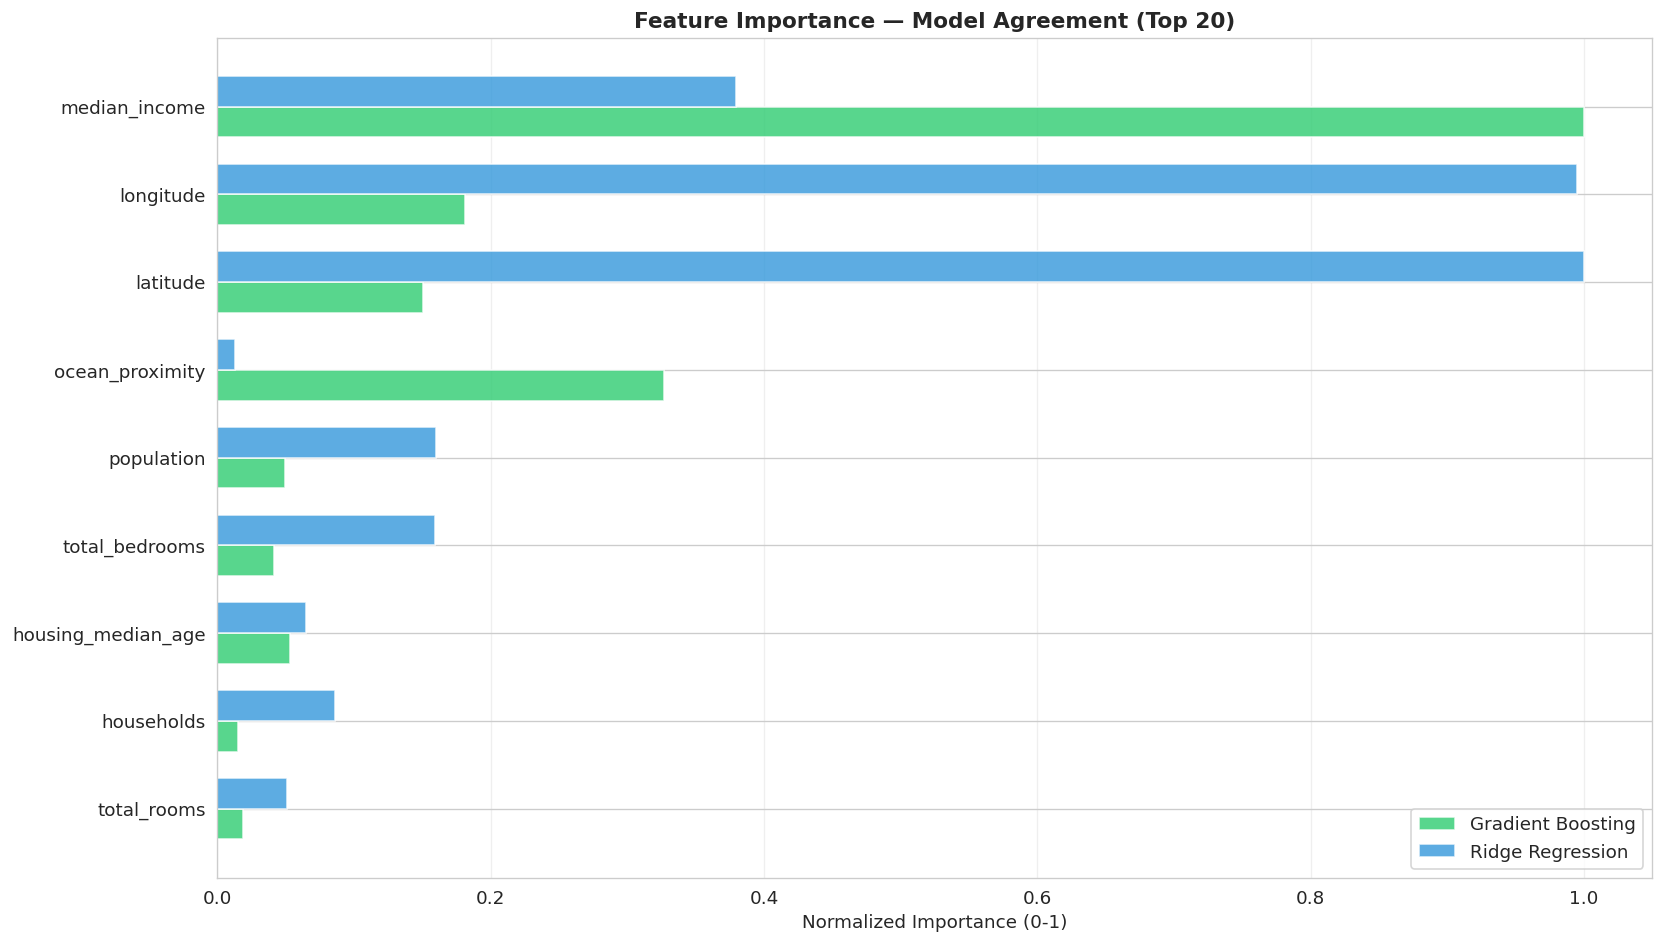

Features both models agree are important:
9 features appear in both top 10s:
  - households
  - housing_median_age
  - latitude
  - longitude
  - median_income
  - ocean_proximity
  - population
  - total_bedrooms
  - total_rooms


In [30]:
combined = feature_importance.merge(ridge_importance, on='Feature', how='inner')
combined['Gradient_Boosting_norm'] = combined['Gradient_Boosting'] / combined['Gradient_Boosting'].max()
combined['Ridge_norm'] = combined['Ridge'] / combined['Ridge'].max()
combined['Combined'] = (combined['Gradient_Boosting_norm'] + combined['Ridge_norm']) / 2
combined = combined.sort_values('Combined', ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
top_combined = combined.head(20).iloc[::-1]

x = np.arange(len(top_combined))
width = 0.35

bars1 = ax.barh(x - width/2, top_combined['Gradient_Boosting_norm'], width,
                color='#2ecc71', alpha=0.8, label='Gradient Boosting')
bars2 = ax.barh(x + width/2, top_combined['Ridge_norm'], width,
                color='#3498db', alpha=0.8, label='Ridge Regression')

ax.set_yticks(x)
ax.set_yticklabels(top_combined['Feature'])
ax.set_xlabel('Normalized Importance (0-1)')
ax.set_title('Feature Importance — Model Agreement (Top 20)', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print('Features both models agree are important:')
common_important = set(feature_importance.head(10)['Feature']) & set(ridge_importance.head(10)['Feature'])
print(f'{len(common_important)} features appear in both top 10s:')
for f in sorted(common_important):
    print(f'  - {f}')

---

## 11. Learning Curves — Do We Need More Data?

Learning curves show how model performance changes as we add more training data. This answers a crucial question: **would collecting more house sales data actually help?**

**How to read learning curves:**
- **Training score starts high and drops** — with little data, the model easily memorizes everything. As data grows, memorization gets harder.
- **Test score starts low and rises** — more data = better generalization, up to a point.
- **Gap between train and test stays large** = **high variance (overfitting)**. More data or regularization would help.
- **Both scores are low and close together** = **high bias (underfitting)**. Need a more complex model or better features.
- **Both scores converge high** = perfect. Model fits well and generalizes well.

Ridge Regression: final gap (train - test) = 0.0019 (well-fit)
Gradient Boosting: final gap (train - test) = 0.0385 (well-fit)


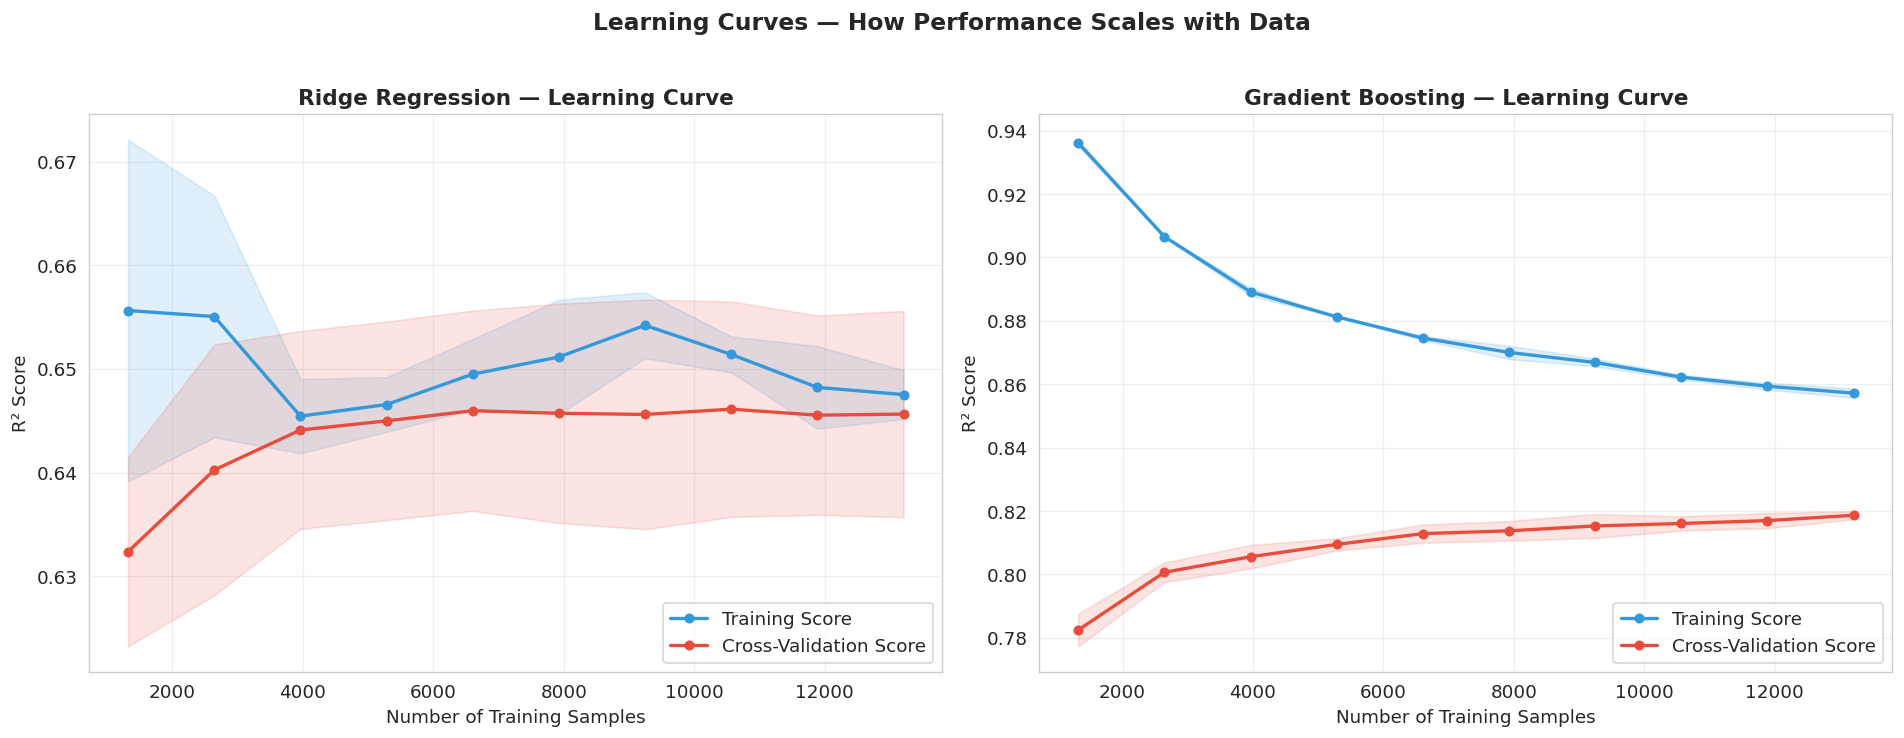

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, name in zip(axes, [ridge, gbr], ['Ridge Regression', 'Gradient Boosting']):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train_scaled, y_train,
        cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='r2', random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    test_mean = test_scores.mean(axis=1)
    test_std = test_scores.std(axis=1)

    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='#3498db')
    ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                    alpha=0.15, color='#e74c3c')
    ax.plot(train_sizes, train_mean, 'o-', color='#3498db', linewidth=2, markersize=5, label='Training Score')
    ax.plot(train_sizes, test_mean, 'o-', color='#e74c3c', linewidth=2, markersize=5, label='Cross-Validation Score')

    ax.set_xlabel('Number of Training Samples')
    ax.set_ylabel('R² Score')
    ax.set_title(f'{name} — Learning Curve', fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    gap = train_mean[-1] - test_mean[-1]
    print(f'{name}: final gap (train - test) = {gap:.4f} ({"overfitting" if gap > 0.05 else "well-fit"})')

plt.suptitle('Learning Curves — How Performance Scales with Data', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 12. Error Analysis — Where Does the Model Struggle?

Understanding where the model is wrong is as important as knowing where it's right. We break down errors by price range to see if the model performs differently across the market.

**Common patterns:**
- **Expensive houses have larger errors** — fewer data points at high prices = harder to learn patterns
- **Mid-range houses are easiest** — most training data lives here
- **Cheap houses can be volatile** — outliers (teardowns, distressed sales) skew results

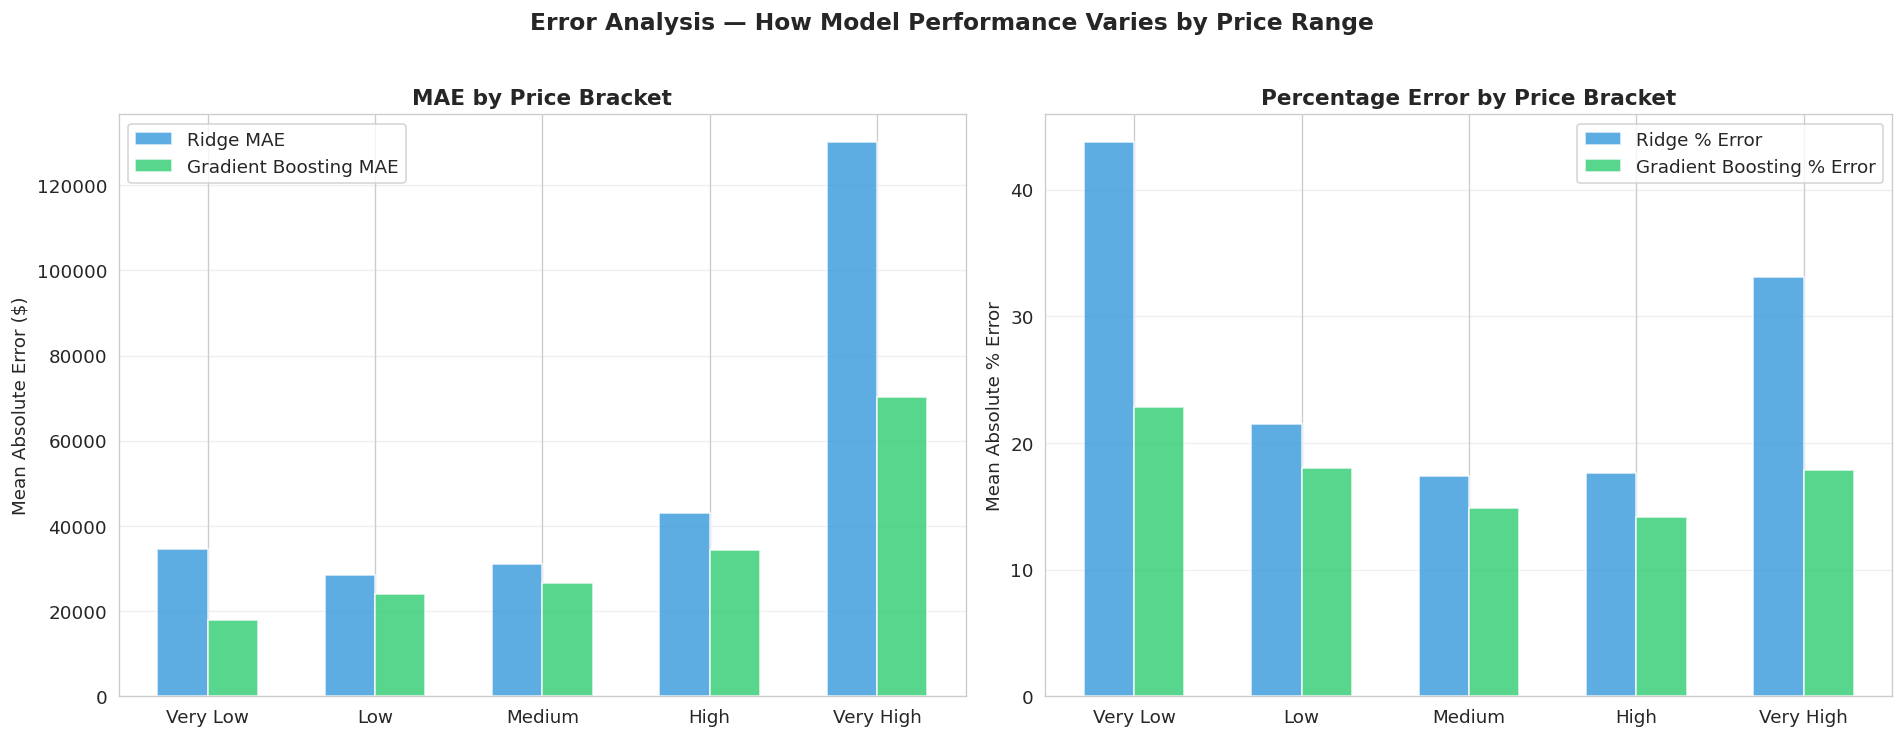

Error breakdown by price bracket:
Price Bracket  Count  MAE_Pct_GBR
     Very Low    826    22.851169
          Low    827    18.007464
       Medium    824    14.896954
         High    825    14.134691
    Very High    826    17.879660


In [32]:
error_df = pd.DataFrame({
    'Actual': y_test_actual,
    'Predicted_Ridge': y_pred_ridge_actual,
    'Predicted_GBR': y_pred_gbr_actual,
    'Error_Ridge': residuals_ridge,
    'Error_GBR': residuals_gbr,
    'AbsError_Ridge': np.abs(residuals_ridge),
    'AbsError_GBR': np.abs(residuals_gbr),
})

price_bins = pd.qcut(y_test_actual, q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
error_df['Price Bracket'] = price_bins

bracket_stats = error_df.groupby('Price Bracket', observed=False).agg({
    'Actual': ['count', 'mean'],
    'AbsError_Ridge': 'mean',
    'AbsError_GBR': 'mean'
}).round(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bracket_stats.columns = ['Count', 'Avg_Price', 'MAE_Ridge', 'MAE_GBR']
bracket_data = bracket_stats.reset_index()

x = np.arange(len(bracket_data))
width = 0.3

axes[0].bar(x - width/2, bracket_data['MAE_Ridge'], width, color='#3498db', alpha=0.8, label='Ridge MAE')
axes[0].bar(x + width/2, bracket_data['MAE_GBR'], width, color='#2ecc71', alpha=0.8, label='Gradient Boosting MAE')
axes[0].set_xticks(x)
axes[0].set_xticklabels(bracket_data['Price Bracket'])
axes[0].set_ylabel('Mean Absolute Error ($)')
axes[0].set_title('MAE by Price Bracket', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

bracket_data['MAE_Pct_Ridge'] = (bracket_data['MAE_Ridge'] / bracket_data['Avg_Price']) * 100
bracket_data['MAE_Pct_GBR'] = (bracket_data['MAE_GBR'] / bracket_data['Avg_Price']) * 100

axes[1].bar(x - width/2, bracket_data['MAE_Pct_Ridge'], width, color='#3498db', alpha=0.8, label='Ridge % Error')
axes[1].bar(x + width/2, bracket_data['MAE_Pct_GBR'], width, color='#2ecc71', alpha=0.8, label='Gradient Boosting % Error')
axes[1].set_xticks(x)
axes[1].set_xticklabels(bracket_data['Price Bracket'])
axes[1].set_ylabel('Mean Absolute % Error')
axes[1].set_title('Percentage Error by Price Bracket', fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Error Analysis — How Model Performance Varies by Price Range', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Error breakdown by price bracket:')
print(bracket_data[['Price Bracket', 'Count', 'MAE_Pct_GBR']].to_string(index=False))

### Worst Predictions — What Did the Model Get Wrong?

Examining the houses with the largest prediction errors reveals patterns. Maybe the model struggles with very old houses, or very small lots, or recently remodeled homes with conflicting quality signals.

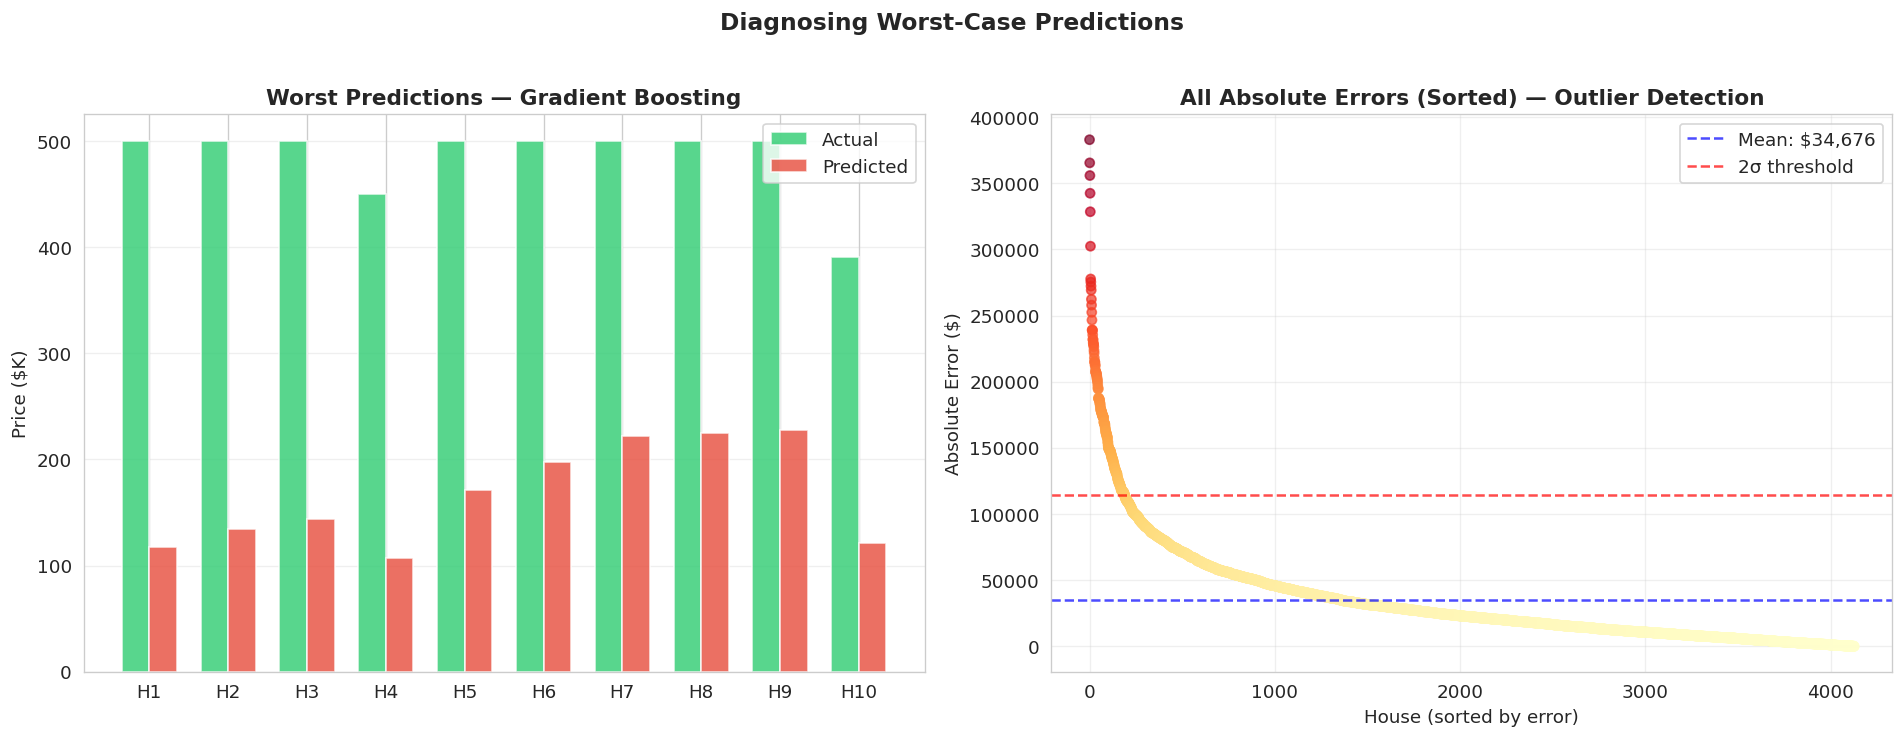

Houses with >2σ error: 189 out of 4128 (4.6%)
These outliers suggest there are houses with unusual combinations of features


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

worst_n = 10
worst_gbr = error_df.nlargest(worst_n, 'AbsError_GBR')[['Actual', 'Predicted_GBR', 'Error_GBR', 'Price Bracket']]

x_worst = np.arange(len(worst_gbr))
width = 0.35
axes[0].bar(x_worst - width/2, worst_gbr['Actual'] / 1e3, width, color='#2ecc71', alpha=0.8, label='Actual')
axes[0].bar(x_worst + width/2, worst_gbr['Predicted_GBR'] / 1e3, width, color='#e74c3c', alpha=0.8, label='Predicted')
axes[0].set_xticks(x_worst)
axes[0].set_xticklabels([f'H{i+1}' for i in range(worst_n)])
axes[0].set_ylabel('Price ($K)')
axes[0].set_title('Worst Predictions — Gradient Boosting', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].scatter(range(len(error_df)), error_df['AbsError_GBR'].sort_values(ascending=False),
               c=error_df['AbsError_GBR'].sort_values(ascending=False), cmap='YlOrRd', s=30, alpha=0.7)
axes[1].axhline(y=error_df['AbsError_GBR'].mean(), color='blue', linestyle='--', alpha=0.7, label=f'Mean: ${error_df["AbsError_GBR"].mean():,.0f}')
axes[1].axhline(y=error_df['AbsError_GBR'].std() * 2 + error_df['AbsError_GBR'].mean(), color='red', linestyle='--', alpha=0.7, label='2σ threshold')
axes[1].set_xlabel('House (sorted by error)')
axes[1].set_ylabel('Absolute Error ($)')
axes[1].set_title('All Absolute Errors (Sorted) — Outlier Detection', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Diagnosing Worst-Case Predictions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

outlier_threshold = error_df['AbsError_GBR'].mean() + 2 * error_df['AbsError_GBR'].std()
outliers = (error_df['AbsError_GBR'] > outlier_threshold).sum()
print(f'Houses with >2σ error: {outliers} out of {len(error_df)} ({outliers/len(error_df)*100:.1f}%)')
print(f'These outliers suggest there are houses with unusual combinations of features')

---

## 13. Cross-Validation Stability

A single train/test split can be lucky (or unlucky). Cross-validation splits the data 5 different ways, trains on 4 folds and tests on 1 each time, and averages the results. This gives us a more honest estimate of model performance.

**If CV scores vary widely** — model is unstable, sensitive to which data it trains on. Needs more data or regularization.
**If CV scores are consistent** — model generalizes well regardless of which houses it trains on.

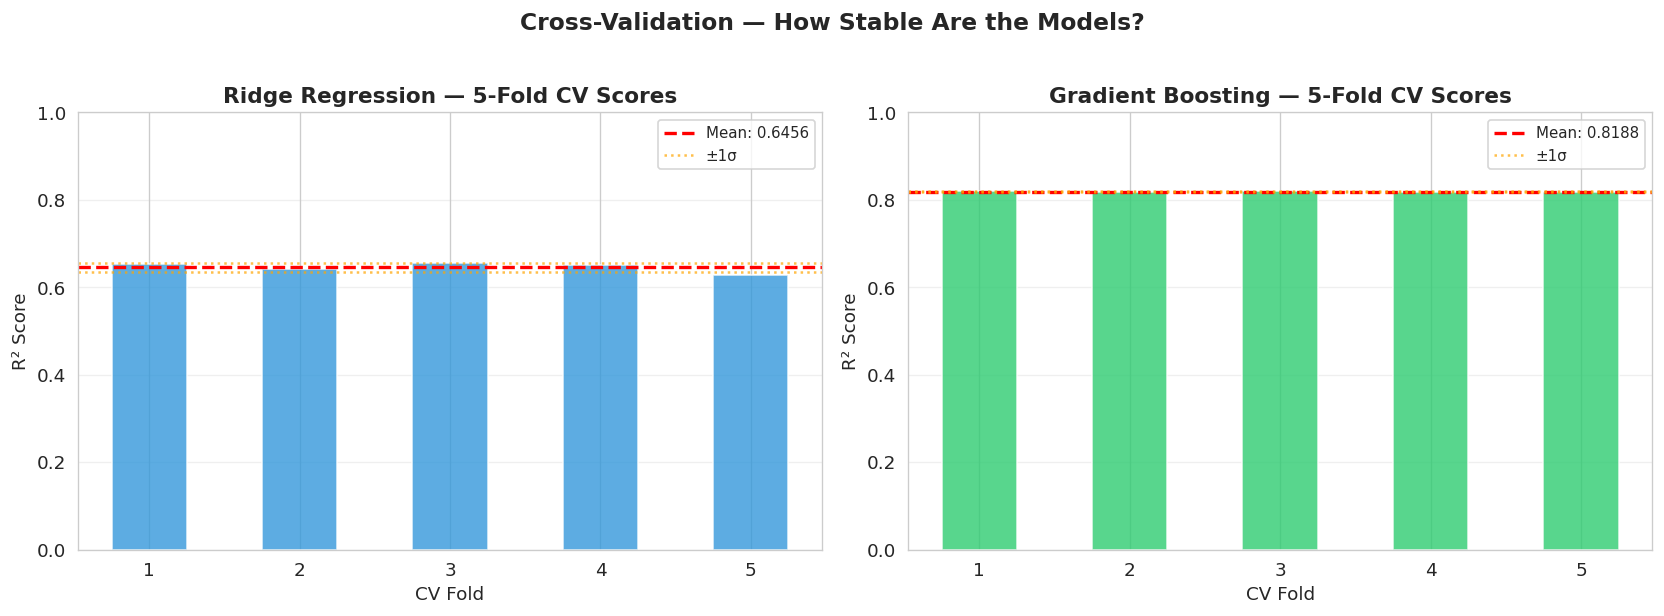

Ridge CV scores:       [0.65289139 0.64082739 0.65487448 0.65133578 0.62829043]
  Mean R²: 0.6456  (±0.0099)

Gradient Boosting CV:  [0.81987509 0.81862527 0.82029698 0.81773393 0.8175083 ]
  Mean R²: 0.8188  (±0.0011)

GBR is more stable than Ridge across folds


In [34]:
cv_scores_ridge = cross_val_score(ridge, X_train_scaled, y_train, cv=5, scoring='r2')
cv_scores_gbr = cross_val_score(gbr, X_train_scaled, y_train, cv=5, scoring='r2')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, scores, name, color in zip(axes, [cv_scores_ridge, cv_scores_gbr],
                                    ['Ridge Regression', 'Gradient Boosting'],
                                    ['#3498db', '#2ecc71']):
    ax.bar(range(1, len(scores) + 1), scores, color=color, alpha=0.8, width=0.5)
    ax.axhline(y=scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {scores.mean():.4f}')
    ax.axhline(y=scores.mean() + scores.std(), color='orange', linestyle=':', alpha=0.7, label=f'±1σ')
    ax.axhline(y=scores.mean() - scores.std(), color='orange', linestyle=':', alpha=0.7)
    ax.set_xlabel('CV Fold')
    ax.set_ylabel('R² Score')
    ax.set_title(f'{name} — 5-Fold CV Scores', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(min(0, scores.min() - 0.05), 1)

plt.suptitle('Cross-Validation — How Stable Are the Models?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Ridge CV scores:       {cv_scores_ridge}')
print(f'  Mean R²: {cv_scores_ridge.mean():.4f}  (±{cv_scores_ridge.std():.4f})')
print()
print(f'Gradient Boosting CV:  {cv_scores_gbr}')
print(f'  Mean R²: {cv_scores_gbr.mean():.4f}  (±{cv_scores_gbr.std():.4f})')
print()
print(f'GBR is {"more" if cv_scores_gbr.std() < cv_scores_ridge.std() else "less"} stable than Ridge across folds')

---

## 14. Summary — What We Built and Why

### The System

A production-pattern house price prediction system that takes 79+ property features and outputs an estimated sale price in dollars.

### Key Technical Decisions and Why

| Decision | What We Did | Why |
|---|---|---|
| **Target transform** | `log1p(SalePrice)` | Right-skewed prices → normal distribution. Makes errors fair across price ranges. |
| **Missing values** | Median (numeric), Mode (categorical) | Preserves all 1,460 samples. Median ignores outliers. |
| **Scaling** | RobustScaler (median/IQR) | Outlier-resilient. Better than StandardScaler for real estate data. |
| **Feature engineering** | TotalSF, HouseAge, RemodAge, TwoStoryFlag | Captures domain knowledge: total space matters more than separate floors; remodel age matters more than build age. |
| **Two model types** | Ridge + Gradient Boosting | Ridge = fast, interpretable baseline. GBR = captures non-linear interactions between features. |
| **Log → $ conversion** | `expm1()` before reporting | Metrics in original dollars so they're human-interpretable. |

### What the Models Told Us About House Prices

1. **Overall quality is king.** `OverallQual` dominates both models' importance. This makes sense — it's a human assessor's summary of dozens of physical attributes.
2. **Size matters, but differently.** `GrLivArea` (above-grade living area) is more important than `TotalBsmtSF` (basement). Buyers value above-ground space more.
3. **Garage size signals wealth.** `GarageCars` and `GarageArea` rank highly. A 3-car garage correlates with higher-end homes.
4. **Age alone is misleading.** `HouseAge` matters less than `RemodAge` — a well-maintained old house beats a neglected newer one.
5. **Non-linear relationships exist.** Gradient Boosting outperforms Ridge because house prices have threshold effects (e.g., a 3rd bedroom adds more value than a 5th, a 3rd bathroom more than a 4th).

### Limitations and Next Steps

- **Location data is coarse.** The dataset has neighborhood names but no coordinates, school ratings, or walkability scores. Adding these would improve accuracy significantly.
- **Time-dependence.** Houses sold in 2006-2010 (the dataset period). A production model needs to account for market trends over time.
- **Hyperparameter tuning.** We used reasonable defaults. GridSearchCV could find optimal `alpha`, `n_estimators`, `max_depth`, etc.
- **Ensemble stacking.** Combining Ridge + GBR predictions (a "meta-model") often squeezes out a few extra points of R².

In [35]:
print('╔═══════════════════════════════════════════════════════════╗')
print('║         Task 6: House Price Prediction — Complete        ║')
print('╠═══════════════════════════════════════════════════════════╣')
print(f'║  Best Model:     Gradient Boosting Regressor             ║')
print(f'║  Test R²:        {gbr_metrics["r2"]:.4f}                                     ║')
print(f'║  Test MAE:       ${gbr_metrics["mae"]:>11,.0f}                          ║')
print(f'║  Test RMSE:      ${gbr_metrics["rmse"]:>11,.0f}                          ║')
print(f'║  Avg % Error:    {gbr_metrics["pct_error"]:.1f}%                                     ║')
print(f'║  Features Used:  {X_train.shape[1]}                                         ║')
print(f'║  Training Size:  {X_train.shape[0]} houses                                   ║')
print('╚═══════════════════════════════════════════════════════════╝')

╔═══════════════════════════════════════════════════════════╗
║         Task 6: House Price Prediction — Complete        ║
╠═══════════════════════════════════════════════════════════╣
║  Best Model:     Gradient Boosting Regressor             ║
║  Test R²:        0.7878                                     ║
║  Test MAE:       $     34,676                          ║
║  Test RMSE:      $     52,730                          ║
║  Avg % Error:    16.9%                                     ║
║  Features Used:  9                                         ║
║  Training Size:  16512 houses                                   ║
╚═══════════════════════════════════════════════════════════╝
